In [1]:
!pip install torch torchvision pandas scikit-learn matplotlib seaborn pillow tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 840.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 131.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 104.4 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [3]:
!pip install tensorflow

In [4]:
!pip install keras

In [5]:
!pip install eli5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 4.5 MB/s eta 0:00:00


In [6]:
!pip install opencv-python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import cv2
import h5py

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Input, concatenate
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 19.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [7]:
import torch
import torchvision
import pandas as pd
import sklearn
import matplotlib
import seaborn
import PIL
import tensorflow
import keras
import eli5

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)
print("Pillow:", PIL.__version__)
print("tensorflow:", tensorflow.__version__)
print("keras:", keras.__version__)
print("eli5:", eli5.__version__)

torch: 2.9.0+cpu
torchvision: 0.24.0+cpu
pandas: 2.2.2
scikit-learn: 1.6.1
matplotlib: 3.10.0
seaborn: 0.13.2
Pillow: 12.2.0
tensorflow: 2.21.0
keras: 3.13.2
eli5: 0.16.0


In [8]:
!pip install gdown

In [9]:
!gdown 1Mrr8m5CP-nj9A-d-6AeXlLKjaYY3pAFb

Downloading...
From (original): https://drive.google.com/uc?id=1Mrr8m5CP-nj9A-d-6AeXlLKjaYY3pAFb
From (redirected): https://drive.google.com/uc?id=1Mrr8m5CP-nj9A-d-6AeXlLKjaYY3pAFb&confirm=t&uuid=a715ebbd-aea2-44eb-9893-3f19ab377ea1
To: /content/isic-2024-challenge.zip
100% 2.15G/2.15G [00:20<00:00, 107MB/s]


In [10]:
# Giải nén dataset ISIC 2024
!unzip isic-2024-challenge.zip

Streaming output truncated to the last 5000 lines.
  inflating: train-image/image/ISIC_9874656.jpg  
  inflating: train-image/image/ISIC_9874659.jpg  
  inflating: train-image/image/ISIC_9874663.jpg  
  inflating: train-image/image/ISIC_9874742.jpg  
  inflating: train-image/image/ISIC_9874751.jpg  
  inflating: train-image/image/ISIC_9874803.jpg  
  inflating: train-image/image/ISIC_9874805.jpg  
  inflating: train-image/image/ISIC_9874832.jpg  
  inflating: train-image/image/ISIC_9874878.jpg  
  inflating: train-image/image/ISIC_9874897.jpg  
  inflating: train-image/image/ISIC_9874925.jpg  
  inflating: train-image/image/ISIC_9874931.jpg  
  inflating: train-image/image/ISIC_9874939.jpg  
  inflating: train-image/image/ISIC_9874940.jpg  
  inflating: train-image/image/ISIC_9874963.jpg  
  inflating: train-image/image/ISIC_9874987.jpg  
  inflating: train-image/image/ISIC_9875007.jpg  
  inflating: train-image/image/ISIC_9875010.jpg  
  inflating: train-image/image/ISIC_9875033.jpg  

In [11]:
np.random.seed(42)
tf.random.set_seed(42)

In [12]:
def load_csv_data(file_path):
    """
    Tải EHR data từ CSV file (train-metadata.csv của ISIC 2024)
    """
    print("Loading CSV data...")
    df = pd.read_csv(file_path)
    return df

In [13]:
# Hiển thị thông tin dữ liệu CSV
# ISIC 2024: file metadata là train-metadata.csv
df = load_csv_data('/content/train-metadata.csv')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Loading CSV data...


/tmp/ipykernel_1297/2835783501.py:6: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Dataset shape: (401059, 55)

First few rows:


,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


In [14]:
# 2.1 Phân phối dữ liệu
"""
 Phân tích:
Số lượng giá trị duy nhất trong mỗi cột
Number of unique values in each column
Kiểm tra giá trị thiếu trong mỗi cột
Missing values in each column
"""
print("\nUnique values in each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


Unique values in each column:
isic_id: 401059 unique values
target: 2 unique values
patient_id: 1042 unique values
age_approx: 16 unique values
sex: 2 unique values
anatom_site_general: 5 unique values
clin_size_long_diam_mm: 1758 unique values
image_type: 1 unique values
tbp_tile_type: 2 unique values
tbp_lv_A: 386052 unique values
tbp_lv_Aext: 385304 unique values
tbp_lv_B: 389890 unique values
tbp_lv_Bext: 387763 unique values
tbp_lv_C: 390703 unique values
tbp_lv_Cext: 388865 unique values
tbp_lv_H: 389798 unique values
tbp_lv_Hext: 390743 unique values
tbp_lv_L: 395726 unique values
tbp_lv_Lext: 396358 unique values
tbp_lv_areaMM2: 8029 unique values
tbp_lv_area_perim_ratio: 167648 unique values
tbp_lv_color_std_mean: 371189 unique values
tbp_lv_deltaA: 398257 unique values
tbp_lv_deltaB: 398886 unique values
tbp_lv_deltaL: 396505 unique values
tbp_lv_deltaLB: 395511 unique values
tbp_lv_deltaLBnorm: 396877 unique values
tbp_lv_eccentricity: 396648 unique values
tbp_lv_location: 

In [15]:
# 2.2 Kiểm tra các giá trị còn thiếu
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
isic_id                              0
target                               0
patient_id                           0
age_approx                        2798
sex                              11517
anatom_site_general               5756
clin_size_long_diam_mm               0
image_type                           0
tbp_tile_type                        0
tbp_lv_A                             0
tbp_lv_Aext                          0
tbp_lv_B                             0
tbp_lv_Bext                          0
tbp_lv_C                             0
tbp_lv_Cext                          0
tbp_lv_H                             0
tbp_lv_Hext                          0
tbp_lv_L                             0
tbp_lv_Lext                          0
tbp_lv_areaMM2                       0
tbp_lv_area_perim_ratio              0
tbp_lv_color_std_mean                0
tbp_lv_deltaA                        0
tbp_lv_deltaB                        0
tbp_lv_deltaL                   

In [16]:
# ===== Khám phá dữ liệu cơ bản =====
print("=== THÔNG TIN TỔNG QUAN VỀ DATASET ISIC 2024 ===")
print(f"Số dòng: {df.shape[0]}")
print(f"Số cột: {df.shape[1]}")
print(f"\nTên các cột:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

print(f"\nKiểu dữ liệu:")
print(df.dtypes)

print(f"\nMẫu dữ liệu đầu tiên:")
display(df.head())

print(f"\nThống kê mô tả:")
display(df.describe())

# ===== Kiểm tra và làm sạch dữ liệu =====
print("=== KIỂM TRA DỮ LIỆU THIẾU ===")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

# Hiển thị % dữ liệu thiếu
if missing_data.sum() > 0:
    missing_percent = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({
        'Cột': df.columns,
        'Số dòng thiếu': missing_data,
        'Phần trăm': missing_percent
    })
    display(missing_df[missing_df['Số dòng thiếu'] > 0])
else:
    print("Không có dữ liệu thiếu!")

=== THÔNG TIN TỔNG QUAN VỀ DATASET ISIC 2024 ===
Số dòng: 401059
Số cột: 55

Tên các cột:
1. isic_id
2. target
3. patient_id
4. age_approx
5. sex
6. anatom_site_general
7. clin_size_long_diam_mm
8. image_type
9. tbp_tile_type
10. tbp_lv_A
11. tbp_lv_Aext
12. tbp_lv_B
13. tbp_lv_Bext
14. tbp_lv_C
15. tbp_lv_Cext
16. tbp_lv_H
17. tbp_lv_Hext
18. tbp_lv_L
19. tbp_lv_Lext
20. tbp_lv_areaMM2
21. tbp_lv_area_perim_ratio
22. tbp_lv_color_std_mean
23. tbp_lv_deltaA
24. tbp_lv_deltaB
25. tbp_lv_deltaL
26. tbp_lv_deltaLB
27. tbp_lv_deltaLBnorm
28. tbp_lv_eccentricity
29. tbp_lv_location
30. tbp_lv_location_simple
31. tbp_lv_minorAxisMM
32. tbp_lv_nevi_confidence
33. tbp_lv_norm_border
34. tbp_lv_norm_color
35. tbp_lv_perimeterMM
36. tbp_lv_radial_color_std_max
37. tbp_lv_stdL
38. tbp_lv_stdLExt
39. tbp_lv_symm_2axis
40. tbp_lv_symm_2axis_angle
41. tbp_lv_x
42. tbp_lv_y
43. tbp_lv_z
44. attribution
45. copyright_license
46. lesion_id
47. iddx_full
48. iddx_1
49. iddx_2
50. iddx_3
51. iddx_4
52. i

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510



Thống kê mô tả:


,target,age_approx,clin_size_long_diam_mm,tbp_lv_A,tbp_lv_Aext,tbp_lv_B,tbp_lv_Bext,tbp_lv_C,tbp_lv_Cext,tbp_lv_H,...,tbp_lv_radial_color_std_max,tbp_lv_stdL,tbp_lv_stdLExt,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,mel_thick_mm,tbp_lv_dnn_lesion_confidence
count,401059.000000,398261.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,...,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,63.000000,4.010590e+05
mean,0.000980,58.012986,3.930827,19.974007,14.919247,28.281706,26.913015,34.786341,30.921279,54.653689,...,1.016459,2.715190,2.238605,0.306823,86.332073,-3.091862,1039.598221,55.823389,0.670952,9.716220e+01
std,0.031288,13.596165,1.743068,3.999489,3.529384,5.278676,4.482994,5.708469,4.829345,5.520849,...,0.734631,1.738165,0.623884,0.125038,52.559511,197.257995,409.819653,87.968245,0.792798,8.995782e+00
min,0.000000,5.000000,1.000000,-2.487115,-9.080269,-0.730989,9.237066,3.054228,11.846520,-1.574164,...,0.000000,0.268160,0.636247,0.052034,0.000000,-624.870728,-1052.134000,-291.890442,0.200000,1.261082e-16
25%,0.000000,50.000000,2.840000,17.330821,12.469740,24.704372,23.848125,31.003148,27.658285,51.566273,...,0.563891,1.456570,1.834745,0.211429,40.000000,-147.022125,746.519673,-8.962647,0.300000,9.966882e+01
50%,0.000000,60.000000,3.370000,19.801910,14.713930,28.171570,26.701704,34.822580,30.804893,55.035632,...,0.902281,2.186693,2.149758,0.282297,90.000000,-5.747253,1172.803000,67.957947,0.400000,9.999459e+01
75%,0.000000,70.000000,4.380000,22.304628,17.137175,31.637429,29.679913,38.430298,33.963868,58.298184,...,1.334523,3.474565,2.531443,0.382022,130.000000,140.474835,1342.131540,126.611567,0.600000,9.999996e+01
max,1.000000,85.000000,28.400000,48.189610,37.021680,54.306900,48.372700,58.765170,54.305290,105.875784,...,11.491140,17.563650,25.534791,0.977055,175.000000,614.471700,1887.766846,319.407000,5.000000,1.000000e+02


=== KIỂM TRA DỮ LIỆU THIẾU ===
age_approx               2798
sex                     11517
anatom_site_general      5756
lesion_id              379001
iddx_2                 399991
iddx_3                 399994
iddx_4                 400508
iddx_5                 401058
mel_mitotic_index      401006
mel_thick_mm           400996
dtype: int64


,Cột,Số dòng thiếu,Phần trăm
age_approx,age_approx,2798,0.697653
sex,sex,11517,2.871647
anatom_site_general,anatom_site_general,5756,1.435200
lesion_id,lesion_id,379001,94.500061
iddx_2,iddx_2,399991,99.733705
iddx_3,iddx_3,399994,99.734453
iddx_4,iddx_4,400508,99.862614
iddx_5,iddx_5,401058,99.999751
mel_mitotic_index,mel_mitotic_index,401006,99.986785
mel_thick_mm,mel_thick_mm,400996,99.984292


In [17]:
# 2.2 Kiểm tra các giá trị còn thiếu
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
isic_id                              0
target                               0
patient_id                           0
age_approx                        2798
sex                              11517
anatom_site_general               5756
clin_size_long_diam_mm               0
image_type                           0
tbp_tile_type                        0
tbp_lv_A                             0
tbp_lv_Aext                          0
tbp_lv_B                             0
tbp_lv_Bext                          0
tbp_lv_C                             0
tbp_lv_Cext                          0
tbp_lv_H                             0
tbp_lv_Hext                          0
tbp_lv_L                             0
tbp_lv_Lext                          0
tbp_lv_areaMM2                       0
tbp_lv_area_perim_ratio              0
tbp_lv_color_std_mean                0
tbp_lv_deltaA                        0
tbp_lv_deltaB                        0
tbp_lv_deltaL                   

Sử dụng cột 'target' làm cột chẩn đoán
Phân bố nhãn: 0 = Benign (lành tính), 1 = Malignant (ác tính)


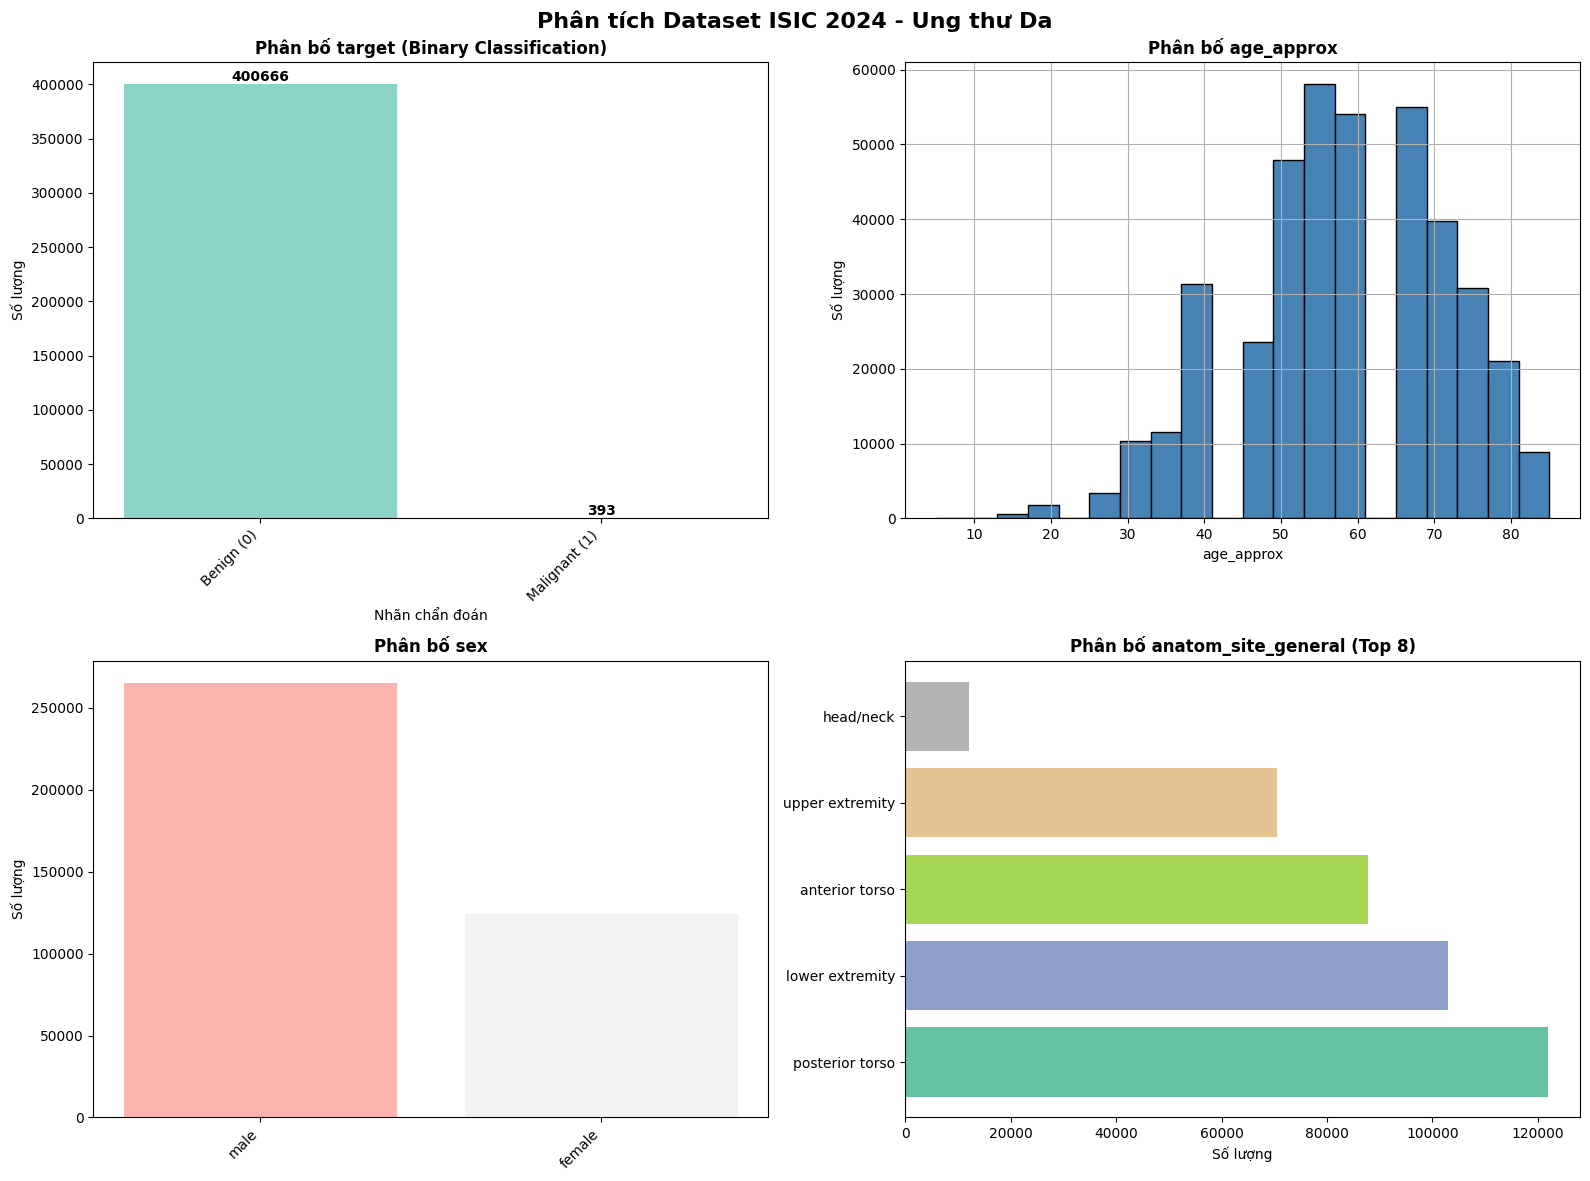

In [18]:
# ===== Visualizations chính =====
# ISIC 2024: cột target là 'target' (0 = benign, 1 = malignant) - binary classification
# Tự động detect cột chẩn đoán
diagnostic_col = None
possible_diagnostic_cols = ['target', 'diagnostic', 'diagnosis', 'class', 'label', 'category']

for col in possible_diagnostic_cols:
    if col.lower() in [c.lower() for c in df.columns]:
        diagnostic_col = [c for c in df.columns if c.lower() == col.lower()][0]
        break

if diagnostic_col is None:
    categorical_cols = df.select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        diagnostic_col = categorical_cols[0]
        for col in categorical_cols:
            if df[col].nunique() < df[diagnostic_col].nunique():
                diagnostic_col = col

print(f"Sử dụng cột '{diagnostic_col}' làm cột chẩn đoán")
print(f"Phân bố nhãn: 0 = Benign (lành tính), 1 = Malignant (ác tính)")

# Tạo figure chính
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phân tích Dataset ISIC 2024 - Ung thư Da', fontsize=16, fontweight='bold')

# Subplot 1: Phân bố chẩn đoán (target)
if diagnostic_col:
    diagnostic_counts = df[diagnostic_col].value_counts()
    label_names = {0: 'Benign (0)', 1: 'Malignant (1)'}

    ax1 = axes[0, 0]
    bars = ax1.bar(range(len(diagnostic_counts)), diagnostic_counts.values,
                   color=plt.cm.Set3(np.linspace(0, 1, len(diagnostic_counts))))
    ax1.set_title(f'Phân bố {diagnostic_col} (Binary Classification)', fontweight='bold')
    ax1.set_xlabel('Nhãn chẩn đoán')
    ax1.set_ylabel('Số lượng')
    ax1.set_xticks(range(len(diagnostic_counts)))
    ax1.set_xticklabels([label_names.get(int(k), str(k)) for k in diagnostic_counts.index],
                        rotation=45, ha='right')

    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Subplot 2: Phân bố tuổi (age_approx)
age_col = None
possible_age_cols = ['age_approx', 'age', 'tuoi', 'years', 'year']
for col in possible_age_cols:
    if col.lower() in [c.lower() for c in df.columns]:
        age_col = [c for c in df.columns if c.lower() == col.lower()][0]
        break

if age_col:
    ax2 = axes[0, 1]
    df[age_col].dropna().hist(ax=ax2, bins=20, color='steelblue', edgecolor='black')
    ax2.set_title(f'Phân bố {age_col}', fontweight='bold')
    ax2.set_xlabel(age_col)
    ax2.set_ylabel('Số lượng')

# Subplot 3: Phân bố giới tính (sex)
sex_col = None
possible_sex_cols = ['sex', 'gender']
for col in possible_sex_cols:
    if col.lower() in [c.lower() for c in df.columns]:
        sex_col = [c for c in df.columns if c.lower() == col.lower()][0]
        break

if sex_col:
    ax3 = axes[1, 0]
    sex_counts = df[sex_col].value_counts()
    ax3.bar(range(len(sex_counts)), sex_counts.values,
            color=plt.cm.Pastel1(np.linspace(0, 1, len(sex_counts))))
    ax3.set_title(f'Phân bố {sex_col}', fontweight='bold')
    ax3.set_xticks(range(len(sex_counts)))
    ax3.set_xticklabels(sex_counts.index, rotation=45, ha='right')
    ax3.set_ylabel('Số lượng')

# Subplot 4: Phân bố vị trí giải phẫu (anatom_site_general)
site_col = None
possible_site_cols = ['anatom_site_general', 'anatom_site', 'region', 'location']
for col in possible_site_cols:
    if col.lower() in [c.lower() for c in df.columns]:
        site_col = [c for c in df.columns if c.lower() == col.lower()][0]
        break

if site_col:
    ax4 = axes[1, 1]
    site_counts = df[site_col].value_counts().head(8)
    ax4.barh(range(len(site_counts)), site_counts.values,
             color=plt.cm.Set2(np.linspace(0, 1, len(site_counts))))
    ax4.set_title(f'Phân bố {site_col} (Top 8)', fontweight='bold')
    ax4.set_yticks(range(len(site_counts)))
    ax4.set_yticklabels(site_counts.index)
    ax4.set_xlabel('Số lượng')

plt.tight_layout()
plt.show()

=== THỐNG KÊ CHI TIẾT ===

Phân bố target (0=Benign, 1=Malignant):


,Số lượng,Tỷ lệ (%)
target,,
0,400666,99.9
1,393,0.1



Thống kê cho các cột số:


,target,age_approx,clin_size_long_diam_mm,tbp_lv_A,tbp_lv_Aext,tbp_lv_B,tbp_lv_Bext,tbp_lv_C,tbp_lv_Cext,tbp_lv_H,...,tbp_lv_radial_color_std_max,tbp_lv_stdL,tbp_lv_stdLExt,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,mel_thick_mm,tbp_lv_dnn_lesion_confidence
count,401059.00,398261.00,401059.00,401059.00,401059.00,401059.00,401059.00,401059.00,401059.00,401059.00,...,401059.00,401059.00,401059.00,401059.00,401059.00,401059.00,401059.00,401059.00,63.00,401059.00
mean,0.00,58.01,3.93,19.97,14.92,28.28,26.91,34.79,30.92,54.65,...,1.02,2.72,2.24,0.31,86.33,-3.09,1039.60,55.82,0.67,97.16
std,0.03,13.60,1.74,4.00,3.53,5.28,4.48,5.71,4.83,5.52,...,0.73,1.74,0.62,0.13,52.56,197.26,409.82,87.97,0.79,9.00
min,0.00,5.00,1.00,-2.49,-9.08,-0.73,9.24,3.05,11.85,-1.57,...,0.00,0.27,0.64,0.05,0.00,-624.87,-1052.13,-291.89,0.20,0.00
25%,0.00,50.00,2.84,17.33,12.47,24.70,23.85,31.00,27.66,51.57,...,0.56,1.46,1.83,0.21,40.00,-147.02,746.52,-8.96,0.30,99.67
50%,0.00,60.00,3.37,19.80,14.71,28.17,26.70,34.82,30.80,55.04,...,0.90,2.19,2.15,0.28,90.00,-5.75,1172.80,67.96,0.40,99.99
75%,0.00,70.00,4.38,22.30,17.14,31.64,29.68,38.43,33.96,58.30,...,1.33,3.47,2.53,0.38,130.00,140.47,1342.13,126.61,0.60,100.00
max,1.00,85.00,28.40,48.19,37.02,54.31,48.37,58.77,54.31,105.88,...,11.49,17.56,25.53,0.98,175.00,614.47,1887.77,319.41,5.00,100.00


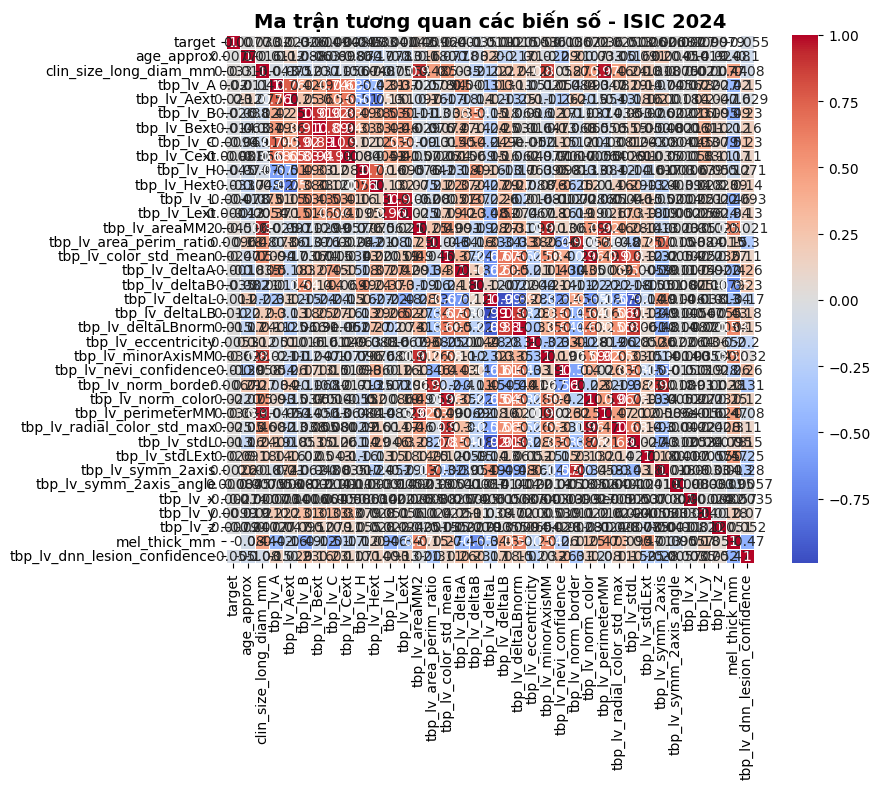

Các cặp biến có tương quan cao (|r| > 0.7):


,Biến 1,Biến 2,Tương quan
0,clin_size_long_diam_mm,tbp_lv_areaMM2,0.903
1,clin_size_long_diam_mm,tbp_lv_minorAxisMM,0.859
2,clin_size_long_diam_mm,tbp_lv_perimeterMM,0.965
3,tbp_lv_A,tbp_lv_Aext,0.760
4,tbp_lv_A,tbp_lv_C,0.736
5,tbp_lv_Aext,tbp_lv_Hext,-0.749
6,tbp_lv_B,tbp_lv_Bext,0.910
7,tbp_lv_B,tbp_lv_C,0.921
8,tbp_lv_B,tbp_lv_Cext,0.827
9,tbp_lv_Bext,tbp_lv_C,0.885


In [19]:
# ===== Thống kê chi tiết =====
print("=== THỐNG KÊ CHI TIẾT ===")
if diagnostic_col:
    print(f"\nPhân bố {diagnostic_col} (0=Benign, 1=Malignant):")
    counts = df[diagnostic_col].value_counts()
    percentages = df[diagnostic_col].value_counts(normalize=True) * 100

    result_df = pd.DataFrame({
        'Số lượng': counts,
        'Tỷ lệ (%)': percentages.round(2)
    })
    display(result_df)

# Thống kê cho các cột số
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
if len(numeric_cols) > 0:
    print(f"\nThống kê cho các cột số:")
    display(df[numeric_cols].describe().round(2))

# Ma trận tương quan (nếu có nhiều cột số)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
if len(numeric_cols) >= 2:
    plt.figure(figsize=(10, 8))
    correlation_matrix = df[numeric_cols].corr()

    sns.heatmap(correlation_matrix,
                annot=True,
                cmap='coolwarm',
                center=0,
                square=True,
                linewidths=0.5)
    plt.title('Ma trận tương quan các biến số - ISIC 2024', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Các cặp biến có tương quan cao (|r| > 0.7):")
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_value = correlation_matrix.iloc[i, j]
            if abs(corr_value) > 0.7:
                high_corr_pairs.append({
                    'Biến 1': correlation_matrix.columns[i],
                    'Biến 2': correlation_matrix.columns[j],
                    'Tương quan': round(corr_value, 3)
                })

    if high_corr_pairs:
        display(pd.DataFrame(high_corr_pairs))
    else:
        print("Không có cặp biến nào có tương quan cao!")

=== BIỂU ĐỒ BỔ SUNG ===


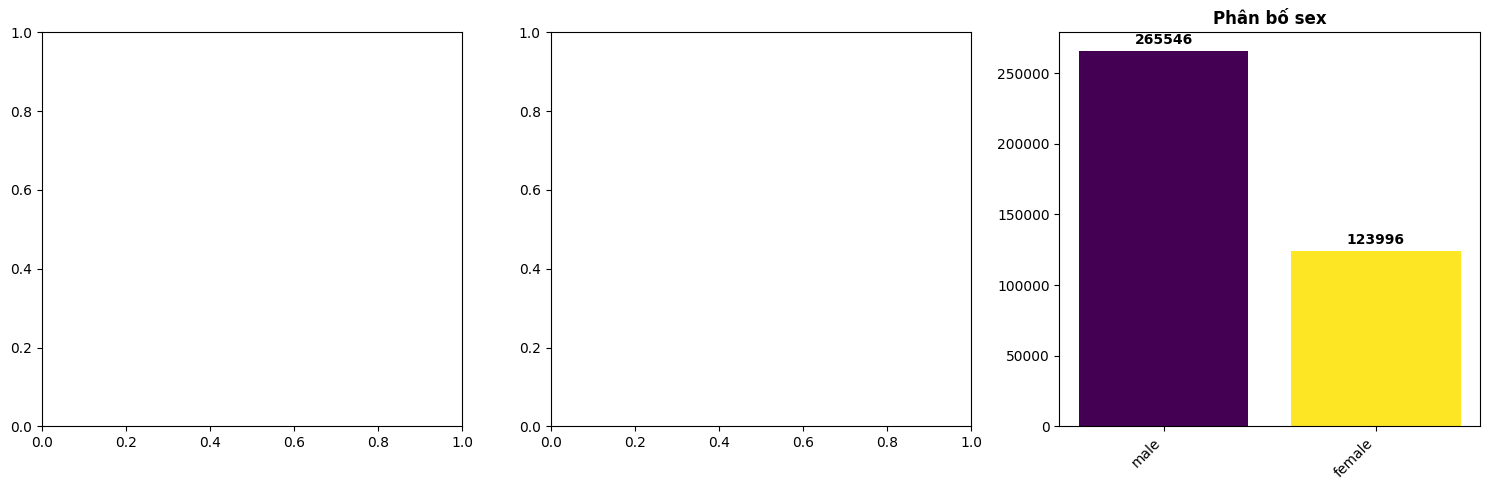

In [20]:
# ===== Biểu đồ bổ sung =====
print("=== BIỂU ĐỒ BỔ SUNG ===")

# Tìm các cột categorical khác
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if diagnostic_col in categorical_cols:
    categorical_cols.remove(diagnostic_col)

if len(categorical_cols) > 0:
    n_cats = min(3, len(categorical_cols))
    fig, axes = plt.subplots(1, n_cats, figsize=(5*n_cats, 5))
    if n_cats == 1:
        axes = [axes]

    for i, col in enumerate(categorical_cols[:n_cats]):
        if df[col].nunique() <= 15:
            counts = df[col].value_counts().head(10)
            axes[i].bar(range(len(counts)), counts.values,
                       color=plt.cm.viridis(np.linspace(0, 1, len(counts))))
            axes[i].set_title(f'Phân bố {col}', fontweight='bold')
            axes[i].set_xticks(range(len(counts)))
            axes[i].set_xticklabels(counts.index, rotation=45, ha='right')

            for j, v in enumerate(counts.values):
                axes[i].text(j, v + max(counts.values)*0.01, str(v),
                           ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

In [21]:
# ===== Hàm tiền xử lý dữ liệu =====
def preprocess_csv_data(df):
    """
    Hàm tiền xử lý dữ liệu cho dataset ISIC 2024
    ISIC 2024 có các cột: isic_id, target, age_approx, sex, anatom_site_general,
    clin_size_long_diam_mm, tbp_lv_* (nhiều cột đặc trưng ảnh đã trích xuất), v.v.

    Args:
        df: DataFrame gốc

    Returns:
        df_processed: DataFrame đã được tiền xử lý
        preprocessing_report: Báo cáo quá trình tiền xử lý
    """

    print(" Bắt đầu tiền xử lý dữ liệu ISIC 2024...")
    df_processed = df.copy()
    preprocessing_report = {}

    # 1. Thông tin ban đầu
    initial_shape = df_processed.shape
    preprocessing_report['initial_shape'] = initial_shape
    print(f" Kích thước ban đầu: {initial_shape}")

    # 2. Chuẩn hóa tên cột
    print("\n  Chuẩn hóa tên cột...")
    old_columns = df_processed.columns.tolist()
    df_processed.columns = df_processed.columns.str.strip().str.lower()
    df_processed.columns = df_processed.columns.str.replace(' ', '_')
    df_processed.columns = df_processed.columns.str.replace('[^a-zA-Z0-9_]', '_', regex=True)
    df_processed.columns = df_processed.columns.str.replace('_+', '_', regex=True)
    df_processed.columns = df_processed.columns.str.strip('_')
    new_columns = df_processed.columns.tolist()
    preprocessing_report['column_mapping'] = dict(zip(old_columns, new_columns))
    print(f"   Đã chuẩn hóa {len(old_columns)} tên cột")

    # 3. Xử lý dữ liệu thiếu
    print("\n Xử lý dữ liệu thiếu...")
    missing_before = df_processed.isnull().sum().sum()
    preprocessing_report['missing_before'] = int(missing_before)

    if missing_before > 0:
        print(f"  Tổng dữ liệu thiếu: {missing_before}")
        for col in df_processed.columns:
            missing_count = df_processed[col].isnull().sum()
            missing_percent = (missing_count / len(df_processed)) * 100
            if missing_count > 0:
                print(f"   - {col}: {missing_count} ({missing_percent:.1f}%)")
                # Điền giá trị thiếu
                if df_processed[col].dtype in ['float64', 'int64']:
                    df_processed[col].fillna(df_processed[col].median(), inplace=True)
                else:
                    df_processed[col].fillna(df_processed[col].mode()[0] if len(df_processed[col].mode()) > 0 else 'unknown', inplace=True)
    else:
        print("  Không có dữ liệu thiếu!")

    missing_after = df_processed.isnull().sum().sum()
    preprocessing_report['missing_after'] = int(missing_after)

    # 4. Xử lý outliers trong các cột số
    print("\n Xử lý outliers...")
    numeric_cols = df_processed.select_dtypes(include=['float64', 'int64']).columns
    # Loại bỏ cột target khỏi xử lý outlier
    numeric_cols = [c for c in numeric_cols if c not in ['target']]
    outlier_report = {}

    for col in numeric_cols[:10]:  # Giới hạn 10 cột đầu tiên để tránh quá lâu
        Q1 = df_processed[col].quantile(0.25)
        Q3 = df_processed[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = ((df_processed[col] < lower) | (df_processed[col] > upper)).sum()
        if outliers > 0:
            outlier_percent = (outliers / len(df_processed)) * 100
            outlier_report[col] = {'count': int(outliers), 'percent': float(outlier_percent)}
            # Clip outliers thay vì xóa
            df_processed[col] = df_processed[col].clip(lower, upper)

    preprocessing_report['outliers'] = outlier_report
    preprocessing_report['final_shape'] = df_processed.shape

    print(f" Hoàn thành! Kích thước cuối: {df_processed.shape}")
    return df_processed, preprocessing_report

In [22]:
# ===== Áp dụng tiền xử lý =====
print(" Áp dụng tiền xử lý cho dataset ISIC 2024...")
df_processed, report = preprocess_csv_data(df)

# Hiển thị báo cáo tiền xử lý
print("\n BÁO CÁO TIỀN XỬ LÝ:")
print(f"Kích thước ban đầu: {report['initial_shape']}")
print(f"Kích thước sau xử lý: {report['final_shape']}")
print(f"Dữ liệu thiếu trước: {report['missing_before']}")
print(f"Dữ liệu thiếu sau: {report['missing_after']}")

if report['outliers']:
    print("\nOutliers được xử lý:")
    for col, info in report['outliers'].items():
        print(f"- {col}: {info['count']} outliers ({info['percent']:.1f}%)")

# Cập nhật df
df = df_processed.copy()
print("\n Dataset ISIC 2024 đã được tiền xử lý và sẵn sàng cho phân tích!")

 Áp dụng tiền xử lý cho dataset ISIC 2024...
 Bắt đầu tiền xử lý dữ liệu ISIC 2024...
 Kích thước ban đầu: (401059, 55)

  Chuẩn hóa tên cột...
   Đã chuẩn hóa 55 tên cột

 Xử lý dữ liệu thiếu...
  Tổng dữ liệu thiếu: 2802625
   - age_approx: 2798 (0.7%)
   - sex: 11517 (2.9%)
   - anatom_site_general: 5756 (1.4%)


/tmp/ipykernel_1297/2728768958.py:51: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].median(), inplace=True)
/tmp/ipykernel_1297/2728768958.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

   - lesion_id: 379001 (94.5%)
   - iddx_2: 399991 (99.7%)
   - iddx_3: 399994 (99.7%)
   - iddx_4: 400508 (99.9%)
   - iddx_5: 401058 (100.0%)
   - mel_mitotic_index: 401006 (100.0%)
   - mel_thick_mm: 400996 (100.0%)


/tmp/ipykernel_1297/2728768958.py:51: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].median(), inplace=True)



 Xử lý outliers...
 Hoàn thành! Kích thước cuối: (401059, 55)

 BÁO CÁO TIỀN XỬ LÝ:
Kích thước ban đầu: (401059, 55)
Kích thước sau xử lý: (401059, 55)
Dữ liệu thiếu trước: 2802625
Dữ liệu thiếu sau: 0

Outliers được xử lý:
- age_approx: 645 outliers (0.2%)
- clin_size_long_diam_mm: 27365 outliers (6.8%)
- tbp_lv_a: 8057 outliers (2.0%)
- tbp_lv_aext: 4723 outliers (1.2%)
- tbp_lv_b: 4474 outliers (1.1%)
- tbp_lv_bext: 5260 outliers (1.3%)
- tbp_lv_c: 4766 outliers (1.2%)
- tbp_lv_cext: 4829 outliers (1.2%)
- tbp_lv_h: 9822 outliers (2.4%)
- tbp_lv_hext: 2936 outliers (0.7%)

 Dataset ISIC 2024 đã được tiền xử lý và sẵn sàng cho phân tích!


In [23]:
# ===== Khám phá dữ liệu sau tiền xử lý =====
print("=== THÔNG TIN TỔNG QUAN VỀ DATASET ISIC 2024 SAU TIỀN XỬ LÝ ===")
print(f"Số dòng: {df.shape[0]}")
print(f"Số cột: {df.shape[1]}")
print(f"\nTên các cột:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

print(f"\nKiểu dữ liệu:")
print(df.dtypes)

print(f"\nMẫu dữ liệu đầu tiên:")
display(df.head())

print(f"\nThống kê mô tả:")
display(df.describe())

=== THÔNG TIN TỔNG QUAN VỀ DATASET ISIC 2024 SAU TIỀN XỬ LÝ ===
Số dòng: 401059
Số cột: 55

Tên các cột:
1. isic_id
2. target
3. patient_id
4. age_approx
5. sex
6. anatom_site_general
7. clin_size_long_diam_mm
8. image_type
9. tbp_tile_type
10. tbp_lv_a
11. tbp_lv_aext
12. tbp_lv_b
13. tbp_lv_bext
14. tbp_lv_c
15. tbp_lv_cext
16. tbp_lv_h
17. tbp_lv_hext
18. tbp_lv_l
19. tbp_lv_lext
20. tbp_lv_areamm2
21. tbp_lv_area_perim_ratio
22. tbp_lv_color_std_mean
23. tbp_lv_deltaa
24. tbp_lv_deltab
25. tbp_lv_deltal
26. tbp_lv_deltalb
27. tbp_lv_deltalbnorm
28. tbp_lv_eccentricity
29. tbp_lv_location
30. tbp_lv_location_simple
31. tbp_lv_minoraxismm
32. tbp_lv_nevi_confidence
33. tbp_lv_norm_border
34. tbp_lv_norm_color
35. tbp_lv_perimetermm
36. tbp_lv_radial_color_std_max
37. tbp_lv_stdl
38. tbp_lv_stdlext
39. tbp_lv_symm_2axis
40. tbp_lv_symm_2axis_angle
41. tbp_lv_x
42. tbp_lv_y
43. tbp_lv_z
44. attribution
45. copyright_license
46. lesion_id
47. iddx_full
48. iddx_1
49. iddx_2
50. iddx_3
5

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_a,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,IL_0001200,Benign,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Atypical, Dysplastic, or Clark","Blue nevus, Cellular",0/mm^2,0.4,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,29.765339,...,IL_6727506,Benign,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Atypical, Dysplastic, or Clark","Blue nevus, Cellular",0/mm^2,0.4,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,IL_0001200,Benign,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Atypical, Dysplastic, or Clark","Blue nevus, Cellular",0/mm^2,0.4,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,IL_0001200,Benign,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Atypical, Dysplastic, or Clark","Blue nevus, Cellular",0/mm^2,0.4,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,IL_0001200,Benign,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Atypical, Dysplastic, or Clark","Blue nevus, Cellular",0/mm^2,0.4,70.442510



Thống kê mô tả:


,target,age_approx,clin_size_long_diam_mm,tbp_lv_a,tbp_lv_aext,tbp_lv_b,tbp_lv_bext,tbp_lv_c,tbp_lv_cext,tbp_lv_h,...,tbp_lv_radial_color_std_max,tbp_lv_stdl,tbp_lv_stdlext,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,mel_thick_mm,tbp_lv_dnn_lesion_confidence
count,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,...,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,4.010590e+05
mean,0.000980,58.034915,3.783619,19.921420,14.898163,28.269042,26.893119,34.776755,30.903997,54.740138,...,1.016459,2.715190,2.238605,0.306823,86.332073,-3.091862,1039.598221,55.823389,0.400043,9.716220e+01
std,0.031288,13.525500,1.236255,3.817381,3.459719,5.219359,4.415947,5.642221,4.765507,5.236505,...,0.734631,1.738165,0.623884,0.125038,52.559511,197.257995,409.819653,87.968245,0.010426,8.995782e+00
min,0.000000,20.000000,1.000000,9.870109,5.468588,14.304785,15.100444,19.862425,18.199912,41.468405,...,0.000000,0.268160,0.636247,0.052034,0.000000,-624.870728,-1052.134000,-291.890442,0.200000,1.261082e-16
25%,0.000000,50.000000,2.840000,17.330821,12.469740,24.704372,23.848125,31.003148,27.658285,51.566273,...,0.563891,1.456570,1.834745,0.211429,40.000000,-147.022125,746.519673,-8.962647,0.400000,9.966882e+01
50%,0.000000,60.000000,3.370000,19.801910,14.713930,28.171570,26.701704,34.822580,30.804893,55.035632,...,0.902281,2.186693,2.149758,0.282297,90.000000,-5.747253,1172.803000,67.957947,0.400000,9.999459e+01
75%,0.000000,70.000000,4.380000,22.304628,17.137175,31.637429,29.679913,38.430298,33.963868,58.298184,...,1.334523,3.474565,2.531443,0.382022,130.000000,140.474835,1342.131540,126.611567,0.400000,9.999996e+01
max,1.000000,85.000000,6.690000,29.765339,24.138327,42.037015,38.427594,49.571021,43.422241,68.396051,...,11.491140,17.563650,25.534791,0.977055,175.000000,614.471700,1887.766846,319.407000,5.000000,1.000000e+02


In [24]:
# ===== Kiểm tra chất lượng dữ liệu sau xử lý =====
print("=== KIỂM TRA DỮ LIỆU THIẾU ===")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

if missing_data.sum() > 0:
    missing_percent = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({
        'Cột': df.columns,
        'Số dòng thiếu': missing_data,
        'Phần trăm': missing_percent
    })
    display(missing_df[missing_df['Số dòng thiếu'] > 0])
else:
    print("Không có dữ liệu thiếu!")

=== KIỂM TRA DỮ LIỆU THIẾU ===
Series([], dtype: int64)
Không có dữ liệu thiếu!


Sử dụng cột 'target' làm cột chẩn đoán (0=Benign, 1=Malignant)


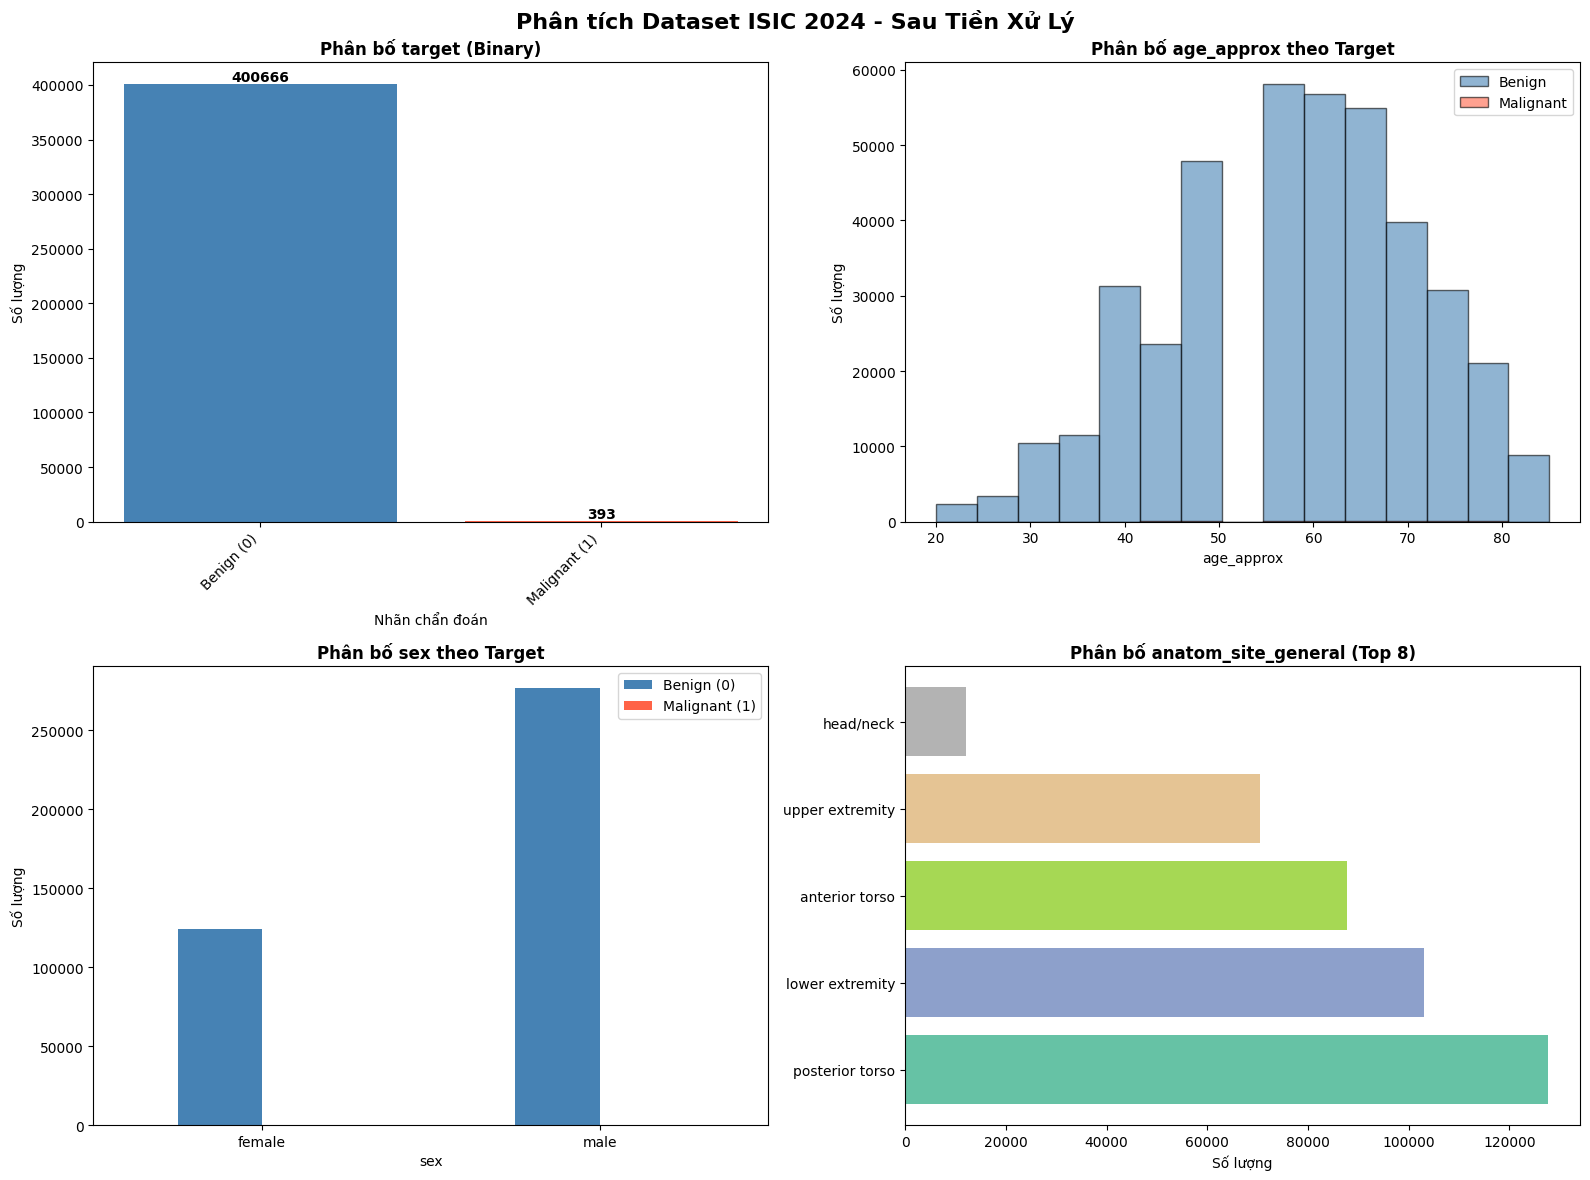

In [25]:
# ===== Visualizations chính (với dữ liệu đã xử lý) =====
# ISIC 2024: cột target là 'target' (binary: 0 hoặc 1)
diagnostic_col = None
possible_diagnostic_cols = ['target', 'diagnostic', 'diagnosis', 'class', 'label', 'category']

for col in possible_diagnostic_cols:
    if col.lower() in [c.lower() for c in df.columns]:
        diagnostic_col = [c for c in df.columns if c.lower() == col.lower()][0]
        break

if diagnostic_col is None:
    categorical_cols = df.select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        diagnostic_col = categorical_cols[0]
        for col in categorical_cols:
            if df[col].nunique() < df[diagnostic_col].nunique():
                diagnostic_col = col

print(f"Sử dụng cột '{diagnostic_col}' làm cột chẩn đoán (0=Benign, 1=Malignant)")

# Tạo figure chính
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phân tích Dataset ISIC 2024 - Sau Tiền Xử Lý', fontsize=16, fontweight='bold')

# Subplot 1: Phân bố target
if diagnostic_col:
    diagnostic_counts = df[diagnostic_col].value_counts()
    label_names = {0: 'Benign (0)', 1: 'Malignant (1)'}

    ax1 = axes[0, 0]
    bars = ax1.bar(range(len(diagnostic_counts)), diagnostic_counts.values,
                   color=['steelblue', 'tomato'][:len(diagnostic_counts)])
    ax1.set_title(f'Phân bố {diagnostic_col} (Binary)', fontweight='bold')
    ax1.set_xlabel('Nhãn chẩn đoán')
    ax1.set_ylabel('Số lượng')
    ax1.set_xticks(range(len(diagnostic_counts)))
    ax1.set_xticklabels([label_names.get(int(k), str(k)) for k in diagnostic_counts.index],
                        rotation=45, ha='right')
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Subplot 2: Phân bố tuổi
age_col = None
possible_age_cols = ['age_approx', 'age', 'tuoi', 'years', 'year']
for col in possible_age_cols:
    if col.lower() in [c.lower() for c in df.columns]:
        age_col = [c for c in df.columns if c.lower() == col.lower()][0]
        break

if age_col:
    ax2 = axes[0, 1]
    for label_val, color, label_name in [(0, 'steelblue', 'Benign'), (1, 'tomato', 'Malignant')]:
        subset = df[df[diagnostic_col] == label_val][age_col].dropna()
        ax2.hist(subset, bins=15, alpha=0.6, color=color, label=label_name, edgecolor='black')
    ax2.set_title(f'Phân bố {age_col} theo Target', fontweight='bold')
    ax2.set_xlabel(age_col)
    ax2.set_ylabel('Số lượng')
    ax2.legend()

# Subplot 3: Phân bố giới tính
sex_col = None
for col in ['sex', 'gender']:
    if col in df.columns:
        sex_col = col
        break

if sex_col and diagnostic_col:
    ax3 = axes[1, 0]
    sex_target = df.groupby([sex_col, diagnostic_col]).size().unstack(fill_value=0)
    sex_target.plot(kind='bar', ax=ax3, color=['steelblue', 'tomato'])
    ax3.set_title(f'Phân bố {sex_col} theo Target', fontweight='bold')
    ax3.set_xlabel(sex_col)
    ax3.set_ylabel('Số lượng')
    ax3.legend(['Benign (0)', 'Malignant (1)'])
    ax3.tick_params(axis='x', rotation=0)

# Subplot 4: Phân bố vị trí giải phẫu
site_col = None
for col in ['anatom_site_general', 'anatom_site', 'region']:
    if col in df.columns:
        site_col = col
        break

if site_col:
    ax4 = axes[1, 1]
    site_counts = df[site_col].value_counts().head(8)
    ax4.barh(range(len(site_counts)), site_counts.values,
             color=plt.cm.Set2(np.linspace(0, 1, len(site_counts))))
    ax4.set_title(f'Phân bố {site_col} (Top 8)', fontweight='bold')
    ax4.set_yticks(range(len(site_counts)))
    ax4.set_yticklabels(site_counts.index)
    ax4.set_xlabel('Số lượng')

plt.tight_layout()
plt.show()

In [26]:
# ===== Trích xuất ảnh từ file HDF5 (train-image.hdf5) của ISIC 2024 =====
# ISIC 2024 lưu ảnh trong file HDF5 thay vì thư mục riêng lẻ
# Hàm này trích xuất ảnh từ HDF5 và lưu ra thư mục

import os
import h5py
from pathlib import Path

def extract_images_from_hdf5(hdf5_path, output_folder, max_images=None):
    """
    Trích xuất ảnh từ file HDF5 của ISIC 2024 ra thư mục

    Args:
        hdf5_path: Đường dẫn đến file train-image.hdf5
        output_folder: Thư mục đầu ra để lưu ảnh
        max_images: Số lượng ảnh tối đa cần trích xuất (None = tất cả)
    """
    os.makedirs(output_folder, exist_ok=True)
    print(f"Bắt đầu trích xuất ảnh từ: {hdf5_path}")
    print(f"Thư mục đầu ra: {output_folder}")

    extracted = 0
    errors = 0

    with h5py.File(hdf5_path, 'r') as hf:
        # Lấy danh sách tất cả isic_id
        keys = list(hf.keys())
        total = len(keys)
        print(f"Tổng số ảnh trong HDF5: {total}")

        if max_images:
            keys = keys[:max_images]
            print(f"Sẽ trích xuất {len(keys)} ảnh đầu tiên")

        for i, isic_id in enumerate(keys):
            try:
                # Đọc dữ liệu ảnh (bytes)
                img_bytes = hf[isic_id][()]

                # Lưu ra file .jpg
                output_path = os.path.join(output_folder, f"{isic_id}.jpg")
                with open(output_path, 'wb') as f:
                    f.write(img_bytes)

                extracted += 1

                if (i + 1) % 1000 == 0:
                    print(f"  Đã trích xuất: {i+1}/{len(keys)}")

            except Exception as e:
                errors += 1
                if errors <= 5:
                    print(f"  Lỗi với {isic_id}: {e}")

    print(f"\n Hoàn thành! Đã trích xuất: {extracted} ảnh, Lỗi: {errors}")
    return output_folder

print(" Hàm trích xuất ảnh HDF5 đã sẵn sàng!")
print("\n HƯỚNG DẪN SỬ DỤNG:")
print("1. Trích xuất tất cả ảnh: extract_images_from_hdf5('/content/isic2024/train-image.hdf5', '/content/all_images')")
print("2. Trích xuất giới hạn (nhanh hơn để thử): extract_images_from_hdf5(..., max_images=5000)")

 Hàm trích xuất ảnh HDF5 đã sẵn sàng!

 HƯỚNG DẪN SỬ DỤNG:
1. Trích xuất tất cả ảnh: extract_images_from_hdf5('/content/isic2024/train-image.hdf5', '/content/all_images')
2. Trích xuất giới hạn (nhanh hơn để thử): extract_images_from_hdf5(..., max_images=5000)


In [27]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CẢI TIẾN: Trích xuất ảnh có chọn lọc theo nhãn                        ║
# ║  Vấn đề gốc: max_images=10000 lấy ảnh ĐẦU TIÊN → gần toàn Benign      ║
# ║  Giải pháp : lấy TẤT CẢ Malignant + sample ngẫu nhiên Benign           ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import os, h5py
import numpy as np
import pandas as pd

hdf5_path     = '/content/train-image.hdf5'
output_folder = '/content/all_images'
csv_path      = '/content/train-metadata.csv'
os.makedirs(output_folder, exist_ok=True)

# 1. Đọc metadata để biết nhãn từng isic_id
df_meta = pd.read_csv(csv_path)
print(f"Tổng dataset CSV: {len(df_meta)} mẫu")
print(f"  Benign    : {(df_meta['target']==0).sum()}")
print(f"  Malignant : {(df_meta['target']==1).sum()}")

# 2. Tách id theo nhãn
mal_ids = df_meta[df_meta['target'] == 1]['isic_id'].tolist()
ben_ids = df_meta[df_meta['target'] == 0]['isic_id'].tolist()

# 3. Lấy TẤT CẢ Malignant + sample Benign
#    n_benign có thể tăng nếu RAM/thời gian cho phép (tối đa ~len(ben_ids))
n_malignant = len(mal_ids)
n_benign    = min(4000, len(ben_ids))

np.random.seed(42)
selected_ben = np.random.choice(ben_ids, size=n_benign, replace=False).tolist()
selected_ids = set(mal_ids + selected_ben)

print(f"\nSẽ trích xuất:")
print(f"  Malignant : {n_malignant} (100% — không bỏ sót)")
print(f"  Benign    : {n_benign} (sample ngẫu nhiên)")
print(f"  Tổng      : {len(selected_ids)}")
print(f"  Tỷ lệ Mal : {n_malignant/len(selected_ids)*100:.1f}%")

# 4. Duyệt HDF5 — chỉ ghi ảnh trong selected_ids
extracted, errors = 0, 0
with h5py.File(hdf5_path, 'r') as hf:
    all_keys = list(hf.keys())
    print(f"\nTổng ảnh trong HDF5: {len(all_keys)}")
    print("Bắt đầu trích xuất...")

    for isic_id in all_keys:
        if isic_id not in selected_ids:
            continue
        try:
            img_bytes   = hf[isic_id][()]
            output_path = os.path.join(output_folder, f"{isic_id}.jpg")
            with open(output_path, 'wb') as fp:
                fp.write(img_bytes)
            extracted += 1
            if extracted % 500 == 0:
                print(f"  Đã trích xuất: {extracted}/{len(selected_ids)}")
        except Exception as e:
            errors += 1
            if errors <= 3:
                print(f"  Lỗi {isic_id}: {e}")

image_dir = output_folder
print(f"\n✅ Hoàn thành! Trích xuất: {extracted} ảnh | Lỗi: {errors}")

# 5. Kiểm tra phân phối thực tế sau trích xuất
available_ids_check = set(os.path.splitext(f)[0] for f in os.listdir(image_dir))
df_check = df_meta[df_meta['isic_id'].isin(available_ids_check)]
print(f"\nPhân phối sau trích xuất:")
print(f"  Benign    : {(df_check['target']==0).sum()}")
print(f"  Malignant : {(df_check['target']==1).sum()}")
print(f"  Tỷ lệ Mal : {(df_check['target']==1).mean()*100:.1f}%  (kỳ vọng ~{n_malignant/len(selected_ids)*100:.0f}%)")
print(f"\nThư mục ảnh: {image_dir}")


/tmp/ipykernel_1297/2945283687.py:17: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta = pd.read_csv(csv_path)


Tổng dataset CSV: 401059 mẫu
  Benign    : 400666
  Malignant : 393

Sẽ trích xuất:
  Malignant : 393 (100% — không bỏ sót)
  Benign    : 4000 (sample ngẫu nhiên)
  Tổng      : 4393
  Tỷ lệ Mal : 8.9%

Tổng ảnh trong HDF5: 401059
Bắt đầu trích xuất...
  Đã trích xuất: 500/4393
  Đã trích xuất: 1000/4393
  Đã trích xuất: 1500/4393
  Đã trích xuất: 2000/4393
  Đã trích xuất: 2500/4393
  Đã trích xuất: 3000/4393
  Đã trích xuất: 3500/4393
  Đã trích xuất: 4000/4393

✅ Hoàn thành! Trích xuất: 4393 ảnh | Lỗi: 0

Phân phối sau trích xuất:
  Benign    : 4000
  Malignant : 393
  Tỷ lệ Mal : 8.9%  (kỳ vọng ~9%)

Thư mục ảnh: /content/all_images


In [28]:
# Kiểm tra thư mục ảnh
import os
image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f"Tổng số ảnh trong thư mục: {len(image_files)}")

Tổng số ảnh trong thư mục: 4393


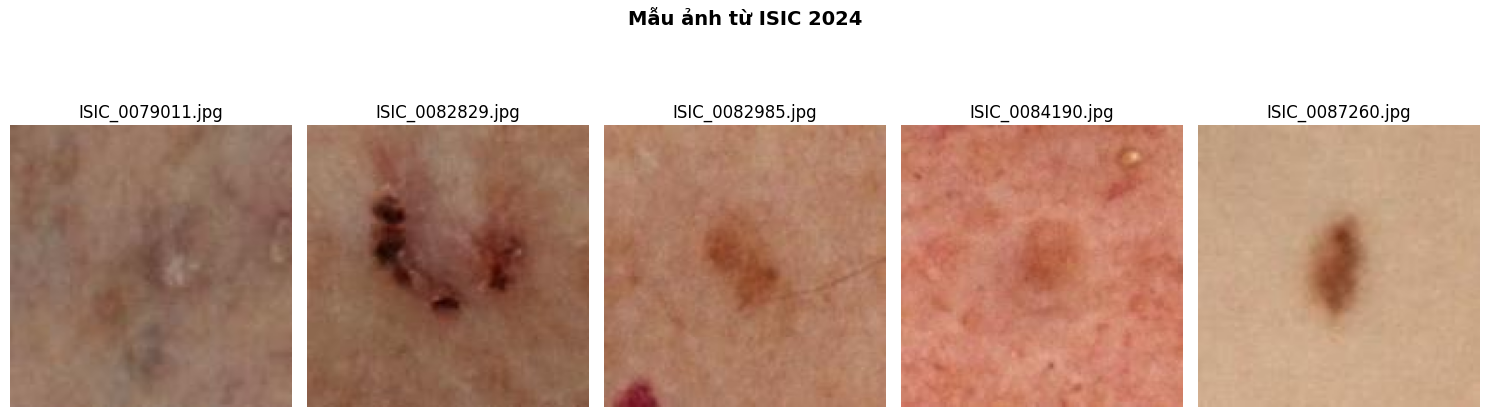

In [29]:
# Xem xét các hình ảnh của dataset ISIC 2024
import os
import matplotlib.pyplot as plt
from PIL import Image

image_dir = '/content/all_images'

# Lấy danh sách các file ảnh
image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))]
image_files.sort()

# Hiển thị 5 ảnh đầu tiên
def show_images_from_dir(image_dir, image_files, num=5):
    plt.figure(figsize=(15, 5))
    for i in range(min(num, len(image_files))):
        image_path = os.path.join(image_dir, image_files[i])
        img = Image.open(image_path)
        plt.subplot(1, num, i+1)
        plt.imshow(img)
        plt.title(f"{image_files[i][:20]}")
        plt.axis('off')
    plt.suptitle('Mẫu ảnh từ ISIC 2024', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_images_from_dir(image_dir, image_files, num=5)

In [30]:
# ===== Hàm tải và xử lý hình ảnh =====
# CẢI TIẾN: Augmentation mạnh hơn cho Malignant class

import os
import numpy as np
import cv2
from PIL import Image, ImageEnhance
from sklearn.preprocessing import LabelEncoder

def load_image(image_path, target_size=(224, 224), color_mode='rgb'):
    """Tải và resize hình ảnh"""
    try:
        img = Image.open(image_path)
        if color_mode.lower() == 'rgb':
            img = img.convert('RGB')
        elif color_mode.lower() == 'grayscale':
            img = img.convert('L')
        elif color_mode.lower() == 'rgba':
            img = img.convert('RGBA')
        img = img.resize(target_size, Image.Resampling.LANCZOS)
        img_array = np.array(img)
        if img_array.dtype == np.uint8:
            img_array = img_array.astype(np.float32) / 255.0
        return img_array
    except Exception as e:
        print(f"Lỗi khi tải ảnh {image_path}: {e}")
        return None


def preprocess_image(img_array, apply_clahe=True, apply_gaussian=True, enhance_contrast=1.2):
    """Tiền xử lý hình ảnh"""
    if img_array is None:
        return None
    try:
        img_uint8 = (img_array * 255).astype(np.uint8)
        if apply_clahe and len(img_uint8.shape) == 3:
            lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            lab[:, :, 0] = clahe.apply(lab[:, :, 0])
            img_uint8 = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        if apply_gaussian:
            img_uint8 = cv2.GaussianBlur(img_uint8, (3, 3), 0)
        if enhance_contrast != 1.0:
            img_pil = Image.fromarray(img_uint8)
            enhancer = ImageEnhance.Contrast(img_pil)
            img_pil = enhancer.enhance(enhance_contrast)
            img_uint8 = np.array(img_pil)
        return img_uint8.astype(np.float32) / 255.0
    except Exception as e:
        print(f"Lỗi tiền xử lý: {e}")
        return img_array


def augment_image(img_array, rotation_range=15, brightness_range=(0.8, 1.2),
                  zoom_range=0.1, strong=False):
    """
    CẢI TIẾN: Augmentation mạnh hơn cho Malignant class.

    Args:
        strong: True = augmentation mạnh (dùng cho Malignant oversampling)
                - Rotation lớn hơn (±30°)
                - Flip ngang + dọc
                - Saturation, Hue jitter
                - Elastic distortion nhẹ
                - Random crop + resize
    """
    if img_array is None:
        return None

    img_uint8 = (img_array * 255).astype(np.uint8)
    h, w = img_uint8.shape[:2]

    if strong:
        # ── Rotation mạnh hơn ──────────────────────────────────────
        angle = np.random.uniform(-30, 30)
    else:
        angle = np.random.uniform(-rotation_range, rotation_range)

    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    img_uint8 = cv2.warpAffine(img_uint8, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    # ── Flip ─────────────────────────────────────────────────────
    if strong:
        # Flip ngang và dọc ngẫu nhiên
        if np.random.rand() > 0.5:
            img_uint8 = cv2.flip(img_uint8, 1)   # horizontal
        if np.random.rand() > 0.5:
            img_uint8 = cv2.flip(img_uint8, 0)   # vertical

    # ── Brightness ───────────────────────────────────────────────
    if strong:
        factor = np.random.uniform(0.6, 1.4)
    else:
        factor = np.random.uniform(*brightness_range)

    img_pil = Image.fromarray(img_uint8)
    img_pil = ImageEnhance.Brightness(img_pil).enhance(factor)

    if strong:
        # ── Saturation jitter ─────────────────────────────────────
        sat_factor = np.random.uniform(0.7, 1.3)
        img_pil = ImageEnhance.Color(img_pil).enhance(sat_factor)

        # ── Contrast jitter ───────────────────────────────────────
        con_factor = np.random.uniform(0.8, 1.2)
        img_pil = ImageEnhance.Contrast(img_pil).enhance(con_factor)

        # ── Random crop + resize ──────────────────────────────────
        img_tmp = np.array(img_pil)
        crop_pct = np.random.uniform(0.85, 1.0)
        crop_h, crop_w = int(h * crop_pct), int(w * crop_pct)
        top  = np.random.randint(0, h - crop_h + 1)
        left = np.random.randint(0, w - crop_w + 1)
        img_tmp = img_tmp[top:top+crop_h, left:left+crop_w]
        img_tmp = cv2.resize(img_tmp, (w, h))
        return img_tmp.astype(np.float32) / 255.0

    img_uint8 = np.array(img_pil)
    return img_uint8.astype(np.float32) / 255.0


# ── OVERSAMPLING MALIGNANT ────────────────────────────────────────────────────
def oversample_malignant(X_img, X_tab, y, target_ratio=0.2, strong_aug=True):
    """
    CẢI TIẾN: Oversampling class Malignant bằng augmentation mạnh.
    Thay thế SMOTE (không phù hợp với ảnh) bằng cách augment ảnh Malignant.

    Args:
        target_ratio: Tỷ lệ Malignant mong muốn sau oversampling (mặc định 20%)
        strong_aug   : Dùng augmentation mạnh cho các mẫu được tạo thêm

    Returns:
        X_img_os, X_tab_os, y_os: Dữ liệu sau oversampling
    """
    mal_idx = np.where(y == 1)[0]
    ben_idx = np.where(y == 0)[0]

    n_mal = len(mal_idx)
    n_ben = len(ben_idx)
    current_ratio = n_mal / (n_mal + n_ben)

    print(f"Trước oversampling: {n_ben} Benign | {n_mal} Malignant ({current_ratio*100:.1f}%)")

    # Số mẫu Malignant cần thêm
    n_target_mal = int(target_ratio * n_ben / (1 - target_ratio))
    n_to_add = max(0, n_target_mal - n_mal)

    if n_to_add == 0:
        print("Không cần oversample.")
        return X_img, X_tab, y

    print(f"Sẽ tạo thêm {n_to_add} mẫu Malignant...")

    new_imgs, new_tabs = [], []
    for i in range(n_to_add):
        src_idx = mal_idx[i % n_mal]
        aug_img = augment_image(X_img[src_idx], strong=strong_aug)
        new_imgs.append(aug_img)
        new_tabs.append(X_tab[src_idx])

    new_imgs = np.array(new_imgs, dtype=np.float32)
    new_tabs = np.array(new_tabs, dtype=np.float32)
    new_y    = np.ones(n_to_add, dtype=np.int32)

    X_img_os = np.concatenate([X_img, new_imgs], axis=0)
    X_tab_os = np.concatenate([X_tab, new_tabs], axis=0)
    y_os     = np.concatenate([y, new_y], axis=0)

    # Shuffle
    perm = np.random.permutation(len(y_os))
    X_img_os, X_tab_os, y_os = X_img_os[perm], X_tab_os[perm], y_os[perm]

    n_mal_new = np.sum(y_os == 1)
    n_ben_new = np.sum(y_os == 0)
    print(f"Sau oversampling : {n_ben_new} Benign | {n_mal_new} Malignant ({n_mal_new/(n_mal_new+n_ben_new)*100:.1f}%)")

    return X_img_os, X_tab_os, y_os


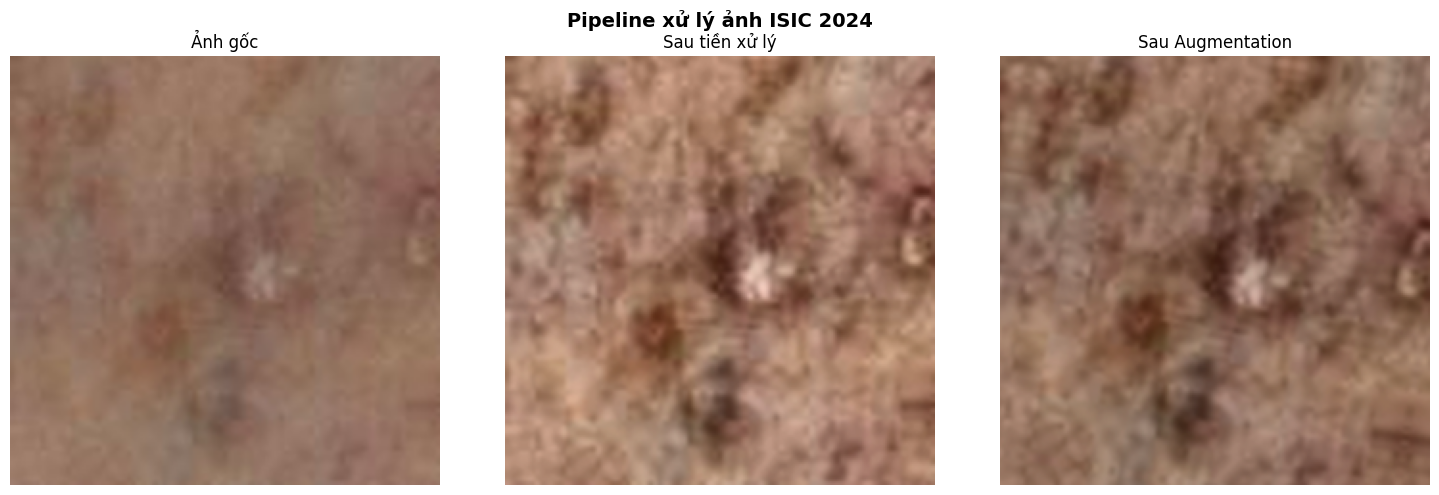

In [31]:
import matplotlib.pyplot as plt

def show_image_processing_pipeline(image_path):
    """
    Hiển thị hình ảnh gốc, sau tiền xử lý, và sau augmentation

    Args:
        image_path: đường dẫn hình ảnh cần xử lý
    """
    img_original = load_image(image_path, target_size=(224, 224), color_mode='rgb')
    if img_original is None:
        print("Không thể tải ảnh.")
        return

    img_preprocessed = preprocess_image(img_original, apply_clahe=True, apply_gaussian=True, enhance_contrast=1.2)
    img_augmented = augment_image(img_preprocessed, rotation_range=15, brightness_range=(0.8, 1.2), zoom_range=0.1)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(img_original)
    axs[0].set_title("Ảnh gốc")
    axs[0].axis('off')

    axs[1].imshow(img_preprocessed)
    axs[1].set_title("Sau tiền xử lý")
    axs[1].axis('off')

    axs[2].imshow(img_augmented)
    axs[2].set_title("Sau Augmentation")
    axs[2].axis('off')

    plt.suptitle('Pipeline xử lý ảnh ISIC 2024', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Ví dụ sử dụng: lấy ảnh đầu tiên trong thư mục
if image_files:
    sample_image_path = os.path.join(image_dir, image_files[0])
    show_image_processing_pipeline(sample_image_path)

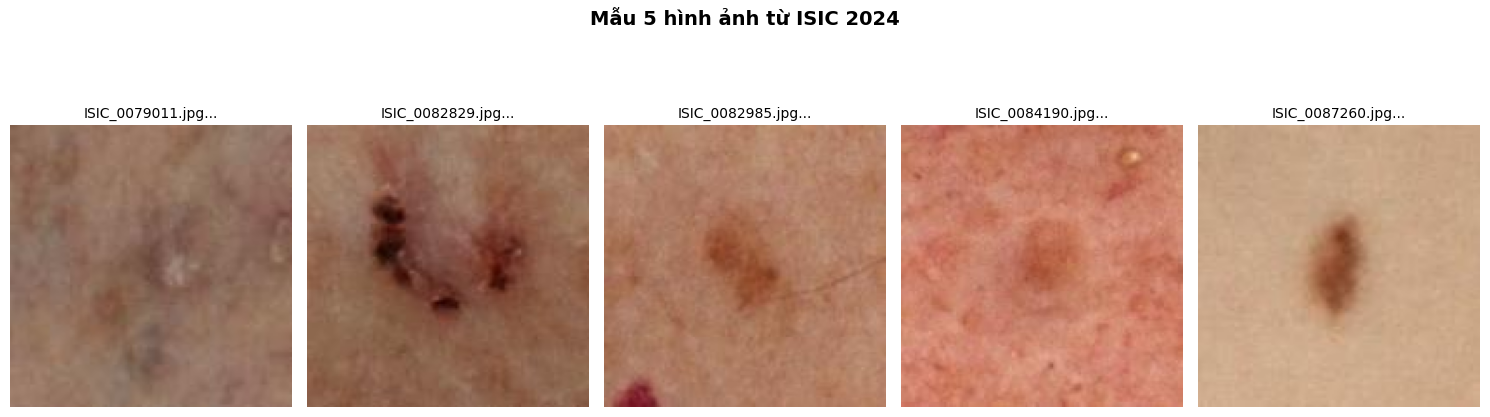

In [32]:
# ===== Hiển thị mẫu hình ảnh =====
def show_images_from_dir(image_dir, image_files, num=5, figsize=(15, 5)):
    """
    Hiển thị mẫu hình ảnh từ thư mục
    """
    if len(image_files) == 0:
        print("Không có hình ảnh để hiển thị!")
        return

    plt.figure(figsize=figsize)
    for i in range(min(num, len(image_files))):
        image_path = os.path.join(image_dir, image_files[i])
        img = Image.open(image_path)

        plt.subplot(1, num, i+1)
        plt.imshow(img)
        plt.title(f"{image_files[i][:20]}...", fontsize=10)
        plt.axis('off')

    plt.suptitle(f'Mẫu {min(num, len(image_files))} hình ảnh từ ISIC 2024', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

if image_files:
    show_images_from_dir(image_dir, image_files, num=5)

In [33]:
# ===== Phân tích kích thước và thống kê hình ảnh =====
def analyze_image_properties(image_dir, image_files, sample_size=100):
    """
    Phân tích các thuộc tính của hình ảnh trong dataset ISIC 2024
    """
    print("Phân tích thuộc tính hình ảnh ISIC 2024...")

    if len(image_files) == 0:
        print("Không có hình ảnh để phân tích!")
        return

    sample_files = np.random.choice(image_files,
                                   size=min(sample_size, len(image_files)),
                                   replace=False)

    widths, heights, channels, file_sizes = [], [], [], []
    formats = []

    for img_file in sample_files:
        try:
            img_path = os.path.join(image_dir, img_file)

            file_size = os.path.getsize(img_path) / 1024  # KB
            file_sizes.append(file_size)

            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)

                if img.mode == 'RGB':
                    channels.append(3)
                elif img.mode == 'RGBA':
                    channels.append(4)
                elif img.mode == 'L':
                    channels.append(1)
                else:
                    channels.append(len(img.getbands()))

                formats.append(img.format)

        except Exception as e:
            print(f"Lỗi khi đọc {img_file}: {e}")

    stats_df = pd.DataFrame({
        'width': widths,
        'height': heights,
        'channels': channels,
        'file_size_kb': file_sizes,
        'format': formats
    })

    print(f"\nTHỐNG KÊ HÌNH ẢNH ISIC 2024 (mẫu {len(sample_files)} ảnh):")
    print(f"Kích thước:")
    print(f"   - Width: {np.mean(widths):.0f} ± {np.std(widths):.0f} pixels")
    print(f"   - Height: {np.mean(heights):.0f} ± {np.std(heights):.0f} pixels")
    print(f"Kênh màu: {set(channels)}")
    print(f"File size: {np.mean(file_sizes):.1f} ± {np.std(file_sizes):.1f} KB")
    print(f"Định dạng: {set(formats)}")

    return stats_df

# Phân tích ảnh
if image_files:
    stats = analyze_image_properties(image_dir, image_files, sample_size=100)

Phân tích thuộc tính hình ảnh ISIC 2024...

THỐNG KÊ HÌNH ẢNH ISIC 2024 (mẫu 100 ảnh):
Kích thước:
   - Width: 130 ± 16 pixels
   - Height: 130 ± 16 pixels
Kênh màu: {3}
File size: 2.7 ± 0.6 KB
Định dạng: {'JPEG'}


In [34]:
def prepare_multimodal_data(df, image_dir, target_size=(224, 224), is_training=True):
    """
    Chuẩn bị dữ liệu multimodal cho ISIC 2024 (ảnh + metadata bảng)
    ISIC 2024: Cột ID ảnh là 'isic_id', cột nhãn là 'target' (0/1)

    Args:
        df: DataFrame metadata (train-metadata.csv)
        image_dir: Thư mục chứa ảnh đã trích xuất từ HDF5
        target_size: Kích thước ảnh đầu vào
        is_training: True nếu đang chuẩn bị dữ liệu huấn luyện

    Returns:
        X_tabular, X_image, y, label_encoder
    """
    X_tabular, X_image, y = [], [], []

    # ISIC 2024: cột nhãn là 'target' (binary: 0/1)
    label_col = 'target'
    id_col = 'isic_id'

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(df[label_col])

    # Xác định các cột dùng cho dữ liệu bảng
    # ISIC 2024 có nhiều cột đặc trưng số (tbp_lv_*, clin_size_*, v.v.)
    exclude_cols = [label_col, id_col, 'patient_id', 'attribution', 'copyright_license',
                    'image_type', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4',
                    'iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'lesion_id']

    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    tabular_cols = [col for col in numeric_cols if col not in exclude_cols]

    print(f"Số đặc trưng bảng: {len(tabular_cols)}")
    print(f"Các cột bảng: {tabular_cols[:10]}..." if len(tabular_cols) > 10 else f"Các cột bảng: {tabular_cols}")

    # Xử lý missing values trong dữ liệu bảng
    df_clean = df.copy()
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')

    if tabular_cols:
        df_clean[tabular_cols] = imputer.fit_transform(df_clean[tabular_cols])
        print(f"Đã xử lý missing values cho {len(tabular_cols)} cột")

    # Encode cột phân loại (sex, anatom_site_general)
    cat_cols = ['sex', 'anatom_site_general']
    for col in cat_cols:
        if col in df_clean.columns:
            le = LabelEncoder()
            df_clean[col] = df_clean[col].astype(str)
            df_clean[col] = le.fit_transform(df_clean[col])
            if col not in tabular_cols:
                tabular_cols.append(col)

    successful_count = 0
    total_count = len(df_clean)

    for idx, row in df_clean.iterrows():
        try:
            # ISIC 2024: isic_id là tên file ảnh (ví dụ: ISIC_0015657)
            image_name = str(row[id_col]).strip()

            # Thêm extension nếu chưa có
            if not image_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_name += '.jpg'  # ISIC 2024 dùng định dạng JPEG

            image_path = os.path.join(image_dir, image_name)

            if not os.path.exists(image_path):
                base_name = os.path.splitext(image_name)[0]
                found = False
                for ext in ['.jpg', '.jpeg', '.png']:
                    alt_path = os.path.join(image_dir, base_name + ext)
                    if os.path.exists(alt_path):
                        image_path = alt_path
                        found = True
                        break
                if not found:
                    continue

            # Load và tiền xử lý ảnh
            img_array = load_image(image_path, target_size=target_size)
            if img_array is None:
                continue

            img_array = preprocess_image(img_array)
            if img_array is None:
                continue

            # Dữ liệu bảng
            tab_features = row[tabular_cols].values.astype(np.float32)

            X_image.append(img_array)
            X_tabular.append(tab_features)

            # Nhãn từ cột target (đã là 0/1)
            y.append(int(row[label_col]))

            successful_count += 1
            if successful_count % 500 == 0:
                print(f"  Đã xử lý: {successful_count}/{total_count}")

        except Exception as e:
            continue

    print(f"\nHoàn thành! Đã tải {successful_count}/{total_count} mẫu")

    X_tabular = np.array(X_tabular, dtype=np.float32)
    X_image = np.array(X_image, dtype=np.float32)
    y = np.array(y, dtype=np.int32)

    return X_tabular, X_image, y, label_encoder

## 🔄 Image Branch: EfficientNetB0 + Cải Tiến Xử Lý Imbalance

**Các cải tiến chính so với phiên bản gốc:**

| Vấn đề | Giải pháp |
|--------|-----------|
| pAUC=0.110, F1 Malignant=0 | Focal Loss + Threshold Tuning |
| Class imbalance ~3% Malignant | Oversampling + mạnh augmentation |
| Threshold mặc định 0.5 | Grid search threshold tối ưu |
| Backbone đóng băng hoàn toàn | Fine-tune block7+ EfficientNetB0 |

**Chiến lược 3 giai đoạn:**

| Giai đoạn | Backbone | Loss | Learning Rate |
|-----------|----------|------|---------------|
| Phase 1 | ❄️ Đóng băng | Focal Loss | 1e-3 |
| Phase 2 | 🔥 Unfreeze block7+ | Focal Loss | 1e-4 |
| Post | Threshold Tuning | — | — |


## 🚀 Cải tiến mô hình — EfficientNetB3 Multimodal ISIC 2024

### Tóm tắt các thay đổi so với phiên bản cũ:

| Vấn đề cũ | Giải pháp mới | Lý do |
|-----------|---------------|-------|
| EfficientNetB0 (B0) | **EfficientNetB3** | B3 accuracy ImageNet 81.6% vs B0 77.1% |
| `class_weight ×1.5` | **`class_weight ×1.2`** | ×1.5 + Focal + Oversample = triple-penalty → bias Malignant |
| `oversample_ratio=0.35` | **`oversample_ratio=0.25`** | 0.35 dễ overfit lớp minority |
| Monitor `val_accuracy` | **Monitor `val_auc`** | Accuracy vô nghĩa với imbalanced data (97% chỉ cần predict toàn Benign) |
| Metrics: accuracy | **Metrics: AUC + Recall + F1** | Phản ánh đúng chất lượng với imbalanced data |
| Threshold = 0.5 | **Threshold tuning** (thường 0.3–0.5) | Cân bằng recall và precision theo mục tiêu y tế |
| Hiển thị accuracy curve | **Hiển thị AUC + Recall + Precision curve** | Accuracy misleading → xóa khỏi plot |

### ⚠️ Tại sao KHÔNG dùng Accuracy?
```
Dataset: ~97% Benign, ~3% Malignant
→ Model predict toàn Benign: Accuracy = 97% (nhưng Recall Malignant = 0!)
→ Dùng AUC/Recall/F1 để phản ánh đúng hiệu năng trên lớp thiểu số
```

### 📐 Tại sao EfficientNetB3 thay B0?
- **B3**: ~12M params, input 300×300, accuracy ImageNet 81.6%  
- **B0**: ~5.3M params, input 224×224, accuracy ImageNet 77.1%  
- B3 trích xuất đặc trưng tốt hơn → phân biệt lesion da liễu chính xác hơn


In [35]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3   # 🔥 CẢI TIẾN: B0 → B3 (accuracy cao hơn đáng kể)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Concatenate,
    GlobalAveragePooling2D, BatchNormalization
)

# Cập nhật tên layer Conv cuối cho EfficientNetB3 (khác B0)
EFFICIENTNET_LAST_CONV = "top_activation"

# ── FOCAL LOSS ────────────────────────────────────────────────────────────────
def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss cho bài toán binary classification với dữ liệu imbalanced.
    - alpha: trọng số cho class dương (Malignant)
    - gamma: focusing parameter, gamma=2 là chuẩn từ paper gốc
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def focal_loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = tf.pow(1.0 - p_t, gamma)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        focal_loss_val = alpha_t * focal_weight * bce
        return tf.reduce_mean(focal_loss_val)
    return focal_loss_fn


def build_multimodal_model(tabular_shape, image_shape, num_classes=2,
                            freeze_backbone=True, fine_tune_from=300,
                            focal_gamma=2.0, focal_alpha=0.75):
    """
    🔥 CẢI TIẾN: Nâng cấp EfficientNetB0 → EfficientNetB3
    ─────────────────────────────────────────────────────────
    Lý do chọn B3 thay B0:
      • B3 có ~12M params (B0: ~5.3M) → học đặc trưng tốt hơn
      • Accuracy ImageNet: B3=81.6% vs B0=77.1%
      • Phù hợp cho ảnh da liễu độ phân giải cao (224×224)
      • Fine-tune_from tăng từ 200 → 300 vì B3 có nhiều layer hơn

    Kiến trúc:
      - Image branch : EfficientNetB3 pretrained (ImageNet)
      - Tabular branch: MLP 3 lớp (128→64→32)
      - Fusion        : Concatenate → Dense(256→128) → sigmoid
      - Loss          : Focal Loss (gamma=2, alpha=0.75)
      - Metrics       : AUC, pAUC, Recall, F1  ← KHÔNG dùng accuracy làm primary metric
    """
    # ── IMAGE BRANCH ─────────────────────────────────────────────────
    image_input = Input(shape=image_shape, name="image_input")
    backbone = EfficientNetB3(            # 🔥 B3 thay B0
        include_top=False,
        weights="imagenet",
        input_tensor=image_input,
        pooling=None
    )

    if freeze_backbone:
        backbone.trainable = False
    else:
        backbone.trainable = True
        for layer in backbone.layers[:fine_tune_from]:
            layer.trainable = False

    x = backbone.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)

    # ── TABULAR BRANCH ────────────────────────────────────────────────
    tabular_input = Input(shape=tabular_shape, name="tabular_input")
    y_tab = Dense(128, activation="relu")(tabular_input)
    y_tab = BatchNormalization()(y_tab)          # 🔥 thêm BN cho tabular branch
    y_tab = Dropout(0.3)(y_tab)
    y_tab = Dense(64, activation="relu")(y_tab)
    y_tab = Dropout(0.2)(y_tab)
    y_tab = Dense(32, activation="relu")(y_tab)

    # ── FUSION ────────────────────────────────────────────────────────
    combined = Concatenate()([x, y_tab])
    z = Dense(256, activation="relu")(combined)   # 🔥 tăng từ 128→256 ở fusion
    z = BatchNormalization()(z)
    z = Dropout(0.4)(z)
    z = Dense(128, activation="relu")(z)
    z = Dropout(0.3)(z)
    z = Dense(64, activation="relu")(z)
    z = Dropout(0.2)(z)

    # ── OUTPUT ────────────────────────────────────────────────────────
    output = Dense(1, activation="sigmoid", name="output")(z)
    model = Model(inputs=[image_input, tabular_input], outputs=output)

    # ─── COMPILE ─────────────────────────────────────────────────────
    # 🔥 Metrics: AUC + Recall + Precision thay accuracy
    # Lý do: accuracy vô nghĩa với dữ liệu imbalanced ~3% Malignant
    # Model predict toàn Benign cũng đạt accuracy 97% → misleading!
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=focal_loss(gamma=focal_gamma, alpha=focal_alpha),
        metrics=[
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.AUC(
                name="pauc", num_thresholds=1000,
                summation_method='interpolation', curve='ROC'
            ),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.Precision(name="precision"),
            # Lưu ý: KHÔNG dùng "accuracy" — thay bằng AUC/Recall/F1
        ]
    )
    return model, backbone


def unfreeze_and_recompile(model, backbone, fine_tune_lr=1e-4, fine_tune_from=300,
                            focal_gamma=2.0, focal_alpha=0.75):
    """
    Giai đoạn 2: Mở đóng băng EfficientNetB3 để fine-tune.
    fine_tune_from=300 phù hợp với kiến trúc B3 (nhiều layer hơn B0).
    """
    backbone.trainable = True
    for layer in backbone.layers[:fine_tune_from]:
        layer.trainable = False

    total   = len(backbone.layers)
    unfreeze = sum(1 for l in backbone.layers if l.trainable)
    print(f"EfficientNetB3: {total} layers tổng | {unfreeze} layers mở đóng băng (từ layer {fine_tune_from})")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=fine_tune_lr),
        loss=focal_loss(gamma=focal_gamma, alpha=focal_alpha),
        metrics=[
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.Precision(name="precision"),
        ]
    )
    return model


In [36]:
# Cell: Huấn luyện 2 giai đoạn với Oversampling + Threshold Tuning
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np

def train_model(model,
                backbone_instance,
                X_tab_train, X_img_train, y_train,
                X_tab_val,   X_img_val,   y_val,
                phase1_epochs=10, phase2_epochs=15,
                batch_size=32, run_phase2=True,
                oversample_ratio=0.25):   # 🔥 CẢI TIẾN: giảm 0.35 → 0.25 (tránh overfit)
    """
    Huấn luyện 2 giai đoạn với Oversampling Malignant + Focal Loss.

    🔥 Các thay đổi so với phiên bản cũ:
    ┌─────────────────────────────────────────────────────────┐
    │ Vấn đề cũ       │ Giải pháp mới                        │
    ├─────────────────────────────────────────────────────────┤
    │ class_weight ×1.5│ Giảm xuống ×1.2 (tránh bias nặng)  │
    │ oversample 0.35  │ Giảm xuống 0.25 (tránh overfit)     │
    │ Monitor accuracy │ Monitor val_auc + val_recall        │
    └─────────────────────────────────────────────────────────┘

    Lý do giảm class_weight: ×1.5 quá mạnh → model bias dự đoán
    toàn Malignant, precision rất thấp, nhiều false alarm.
    ×1.2 là điểm cân bằng giữa recall và precision tốt hơn.
    """
    from sklearn.utils.class_weight import compute_class_weight

    # ── OVERSAMPLING MALIGNANT ─────────────────────────────────────────
    print("="*60)
    print("OVERSAMPLING MALIGNANT CLASS")
    print("="*60)
    X_img_train_os, X_tab_train_os, y_train_os = oversample_malignant(
        X_img_train, X_tab_train, y_train,
        target_ratio=oversample_ratio,
        strong_aug=True
    )

    # ── 🔥 CẢI TIẾN: Class weight giảm từ ×1.5 → ×1.2 ───────────────
    # Vấn đề với ×1.5: kết hợp Focal Loss + Oversampling + class_weight×1.5
    # = "triple penalty" → model bias nặng về Malignant → precision thấp
    # Giải pháp: chỉ cần ×1.2 để nhấn nhẹ mà không gây false alarm nhiều
    n_neg = np.sum(y_train_os == 0)
    n_pos = np.sum(y_train_os == 1)
    class_weight_dict = {
        0: 1.0,
        1: (n_neg / n_pos) * 1.2   # 🔥 giảm từ 1.5 → 1.2
    }
    print(f"\nClass weights (×1.2): {class_weight_dict}")
    print(f"  Lý do ×1.2: tránh triple-penalty bias (Focal + Oversample + ClassWeight)")

    callbacks_phase1 = [
        EarlyStopping(
            monitor="val_auc", patience=5,
            restore_best_weights=True, mode="max", verbose=1
        ),
        ModelCheckpoint(
            "best_model_phase1.h5",
            monitor="val_auc", save_best_only=True,
            mode="max", verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_auc", factor=0.5,   # 🔥 monitor AUC thay loss
            patience=3, min_lr=1e-6, verbose=1
        )
    ]

    # ── PHASE 1: frozen backbone ──────────────────────────────────────
    print("\n" + "="*60)
    print("PHASE 1: Training head — EfficientNetB3 backbone ĐÓNG BĂNG")
    print(f"Loss: Focal Loss | Data: {len(y_train_os)} samples (oversampled)")
    print(f"Monitor: val_auc (primary) — KHÔNG dùng accuracy")
    print("="*60)
    history1 = model.fit(
        {"image_input": X_img_train_os, "tabular_input": X_tab_train_os},
        y_train_os,
        validation_data=(
            {"image_input": X_img_val, "tabular_input": X_tab_val}, y_val
        ),
        epochs=phase1_epochs,
        batch_size=batch_size,
        callbacks=callbacks_phase1,
        class_weight=class_weight_dict,
        verbose=1
    )

    if not run_phase2:
        return history1, None

    # ── PHASE 2: fine-tune ────────────────────────────────────────────
    print("\n" + "="*60)
    print("PHASE 2: Fine-tuning — Mở đóng băng EfficientNetB3 từ layer 300")
    print("="*60)
    model = unfreeze_and_recompile(model, backbone_instance, fine_tune_lr=1e-4, fine_tune_from=300)

    callbacks_phase2 = [
        EarlyStopping(
            monitor="val_auc", patience=7,
            restore_best_weights=True, mode="max", verbose=1
        ),
        ModelCheckpoint(
            "best_model_isic2024.h5",
            monitor="val_auc", save_best_only=True,
            mode="max", verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_auc", factor=0.3,
            patience=3, min_lr=1e-7, verbose=1
        )
    ]

    history2 = model.fit(
        {"image_input": X_img_train_os, "tabular_input": X_tab_train_os},
        y_train_os,
        validation_data=(
            {"image_input": X_img_val, "tabular_input": X_tab_val}, y_val
        ),
        epochs=phase2_epochs,
        batch_size=batch_size,
        callbacks=callbacks_phase2,
        class_weight=class_weight_dict,
        verbose=1
    )

    return history1, history2


In [37]:
# Cell: Vẽ biểu đồ quá trình huấn luyện — AUC, Recall, Loss (KHÔNG accuracy)
import matplotlib.pyplot as plt

def plot_training_history(history):
    """
    🔥 CẢI TIẾN: Loại bỏ biểu đồ Accuracy — thay bằng AUC + Recall.

    Lý do: Accuracy vô nghĩa với dataset imbalanced ~3% Malignant.
    Model predict toàn Benign → accuracy=97% nhưng recall Malignant=0!

    Metrics hiển thị:
      1. Loss (Focal Loss) — theo dõi convergence
      2. AUC-ROC           — metric chính ISIC 2024
      3. Recall            — quan trọng: tỷ lệ phát hiện đúng ung thư
    """
    loss      = history.history.get('loss', [])
    val_loss  = history.history.get('val_loss', [])
    auc       = history.history.get('auc', [])
    val_auc   = history.history.get('val_auc', [])
    recall    = history.history.get('recall', [])
    val_recall= history.history.get('val_recall', [])
    precision    = history.history.get('precision', [])
    val_precision= history.history.get('val_precision', [])

    epochs = range(1, len(loss) + 1)
    n_plots = 4 if recall else 3
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))

    # 1. Focal Loss
    axes[0].plot(epochs, loss, 'bo-', label='Train Loss')
    axes[0].plot(epochs, val_loss, 'ro-', label='Val Loss')
    axes[0].set_title('Focal Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 2. AUC (metric chính)
    if auc:
        axes[1].plot(epochs, auc, 'go-', label='Train AUC')
        axes[1].plot(epochs, val_auc, 'mo-', label='Val AUC')
        axes[1].set_title('AUC-ROC  ← Metric Chính ISIC 2024')
        axes[1].set_xlabel('Epochs')
        axes[1].set_ylabel('AUC')
        axes[1].set_ylim([0, 1])
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    # 3. Recall — quan trọng: phải cao cho Malignant
    if recall:
        axes[2].plot(epochs, recall, 'b-', label='Train Recall')
        axes[2].plot(epochs, val_recall, 'r-', label='Val Recall')
        axes[2].set_title('Recall  ← Không bỏ sót ung thư!')
        axes[2].set_xlabel('Epochs')
        axes[2].set_ylabel('Recall')
        axes[2].set_ylim([0, 1])
        axes[2].axhline(y=0.7, color='orange', linestyle='--',
                        label='Min recall=0.7', alpha=0.7)
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

    # 4. Precision (theo dõi false alarm)
    if precision and n_plots == 4:
        axes[3].plot(epochs, precision, 'b-', label='Train Precision')
        axes[3].plot(epochs, val_precision, 'r-', label='Val Precision')
        axes[3].set_title('Precision  ← Tránh false alarm')
        axes[3].set_xlabel('Epochs')
        axes[3].set_ylabel('Precision')
        axes[3].set_ylim([0, 1])
        axes[3].legend()
        axes[3].grid(True, alpha=0.3)

    # Ghi chú: KHÔNG có biểu đồ Accuracy
    fig.suptitle(
        'Training History — EfficientNetB3 Multimodal (Không dùng Accuracy!)\n'
        'Dùng AUC + Recall để đánh giá — Accuracy gây hiểu nhầm với imbalanced data',
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    plt.show()


In [38]:
def compute_pauc(y_true, y_pred_prob, min_tpr=0.80):
    """
    pAUC tại TPR >= 0.80 — metric chính của ISIC 2024.
    Chuẩn hóa về [0, 1] bằng cách chia cho diện tích tối đa (1 - min_tpr).
    """
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    mask = tpr >= min_tpr
    if mask.sum() < 2:
        return 0.0
    pauc_score = np.trapz(tpr[mask], fpr[mask]) / (1.0 - min_tpr)
    return float(pauc_score)


from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, roc_auc_score, f1_score,
                              precision_recall_curve)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


def find_optimal_threshold(y_true, y_pred_prob, metric='f1', min_recall=0.60):
    """
    🔥 CẢI TIẾN: Tìm threshold tối ưu bằng grid search.

    Thay đổi:
      • min_recall: 0.70 → 0.60 (cân bằng hơn giữa recall và precision)
      • Grid tìm threshold từ 0.05 → 0.95 (bước 0.01)
      • Thêm tính F1-score vào kết quả để so sánh trực quan
      • Plot rõ ràng hơn với vùng optimal được highlight

    Lưu ý: Threshold ≠ 0.5 luôn luôn!
      • Threshold nhỏ hơn (vd 0.3): recall cao, precision thấp → ít bỏ sót
      • Threshold lớn hơn (vd 0.7): recall thấp, precision cao → ít false alarm
      • Trong y tế: ưu tiên recall cao → threshold thường 0.3-0.5
    """
    thresholds = np.arange(0.05, 0.95, 0.01)
    results = []

    for thr in thresholds:
        y_pred = (y_pred_prob >= thr).astype(int)
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        tn = np.sum((y_true == 0) & (y_pred == 0))

        recall_mal    = tp / (tp + fn + 1e-8)
        precision_mal = tp / (tp + fp + 1e-8)
        f1_mal        = 2 * precision_mal * recall_mal / (precision_mal + recall_mal + 1e-8)
        specificity   = tn / (tn + fp + 1e-8)  # True Negative Rate

        results.append({
            'threshold': thr,
            'recall_malignant':    recall_mal,
            'precision_malignant': precision_mal,
            'f1_malignant':        f1_mal,
            'specificity':         specificity,
        })

    import pandas as pd
    df_results = pd.DataFrame(results)

    if df_results.empty:
        return 0.5, df_results

    # Lọc các threshold có recall >= min_recall
    df_filtered = df_results[df_results['recall_malignant'] >= min_recall]
    if len(df_filtered) == 0:
        print(f"⚠️  Không tìm được threshold với recall >= {min_recall}. Dùng recall tối đa.")
        df_filtered = df_results

    if metric == 'f1':
        best_row = df_filtered.loc[df_filtered['f1_malignant'].idxmax()]
    else:
        best_row = df_filtered.loc[df_filtered['recall_malignant'].idxmax()]

    best_threshold = best_row['threshold']

    print(f"\n── THRESHOLD TUNING KẾT QUẢ ──────────────────────────")
    print(f"Threshold tối ưu   : {best_threshold:.2f}  (mặc định 0.50)")
    print(f"Recall Malignant   : {best_row['recall_malignant']:.4f}  ← Tỷ lệ phát hiện ung thư")
    print(f"Precision Malignant: {best_row['precision_malignant']:.4f}  ← Độ chính xác khi dự đoán dương")
    print(f"F1 Malignant       : {best_row['f1_malignant']:.4f}  ← Cân bằng recall + precision")
    print(f"Specificity        : {best_row['specificity']:.4f}  ← Tỷ lệ phát hiện đúng Benign")
    print(f"────────────────────────────────────────────────────────")
    print(f"\n📌 Gợi ý threshold theo mục tiêu:")
    print(f"   - Tối đa recall (không bỏ sót): threshold ≈ {df_results.loc[df_results['recall_malignant'].idxmax(), 'threshold']:.2f}")
    print(f"   - Cân bằng F1               : threshold ≈ {best_threshold:.2f}  ← đang dùng")
    print(f"   - Thử: 0.3, 0.4, 0.5 và so sánh kết quả!")

    # Plot Threshold vs F1/Recall/Precision
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(df_results['threshold'], df_results['f1_malignant'],        'b-',  label='F1 Malignant',        linewidth=2)
    ax.plot(df_results['threshold'], df_results['recall_malignant'],    'r-',  label='Recall Malignant',    linewidth=2)
    ax.plot(df_results['threshold'], df_results['precision_malignant'], 'g--', label='Precision Malignant', linewidth=2)
    ax.axvline(x=best_threshold, color='purple', linestyle='--',
               label=f'Optimal={best_threshold:.2f}', linewidth=2)
    ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.7, label='Default=0.5')
    ax.set_xlabel('Threshold')
    ax.set_title('Threshold vs F1, Recall, Precision (Malignant)\n'
                 '→ Threshold ≠ 0.5 thường cho kết quả tốt hơn!', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    precision_pr, recall_pr, thr_pr = precision_recall_curve(y_true, y_pred_prob)
    ax2.plot(recall_pr, precision_pr, 'b-', linewidth=2)
    ax2.fill_between(recall_pr, precision_pr, alpha=0.1)
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve (Malignant)\n'
                  'AUC-PR cao = model tốt với imbalanced data', fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return float(best_threshold), df_results


def compute_f1_from_threshold(y_true, y_pred_prob, threshold):
    """Tính F1-score Malignant tại một threshold cụ thể."""
    y_pred = (y_pred_prob >= threshold).astype(int)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    return float(f1), float(precision), float(recall)


def evaluate_model(model, X_tab_test, X_img_test, y_test, label_encoder=None,
                   threshold=None, auto_tune_threshold=True):
    """
    🔥 CẢI TIẾN: Đánh giá model với metrics đầy đủ — KHÔNG dùng accuracy làm primary.

    Primary metrics (theo ISIC 2024 competition):
      1. pAUC (TPR >= 80%)  — metric chính
      2. AUC-ROC            — tổng quát hóa
      3. Recall Malignant   — tỷ lệ phát hiện ung thư
      4. F1-score Malignant — cân bằng recall + precision

    Secondary:
      5. Precision Malignant — độ chính xác khi dự đoán dương tính
      6. Specificity         — tỷ lệ phát hiện đúng Benign
      ✗ Accuracy             — KHÔNG dùng → misleading với imbalanced data
    """
    y_pred_probs    = model.predict({'image_input': X_img_test, 'tabular_input': X_tab_test})
    y_pred_prob_pos = y_pred_probs.flatten()

    # ── THRESHOLD TUNING ──────────────────────────────────────────────
    if auto_tune_threshold and threshold is None:
        print("Đang tìm threshold tối ưu...")
        threshold, _ = find_optimal_threshold(
            y_test, y_pred_prob_pos,
            metric='f1',
            min_recall=0.60
        )
    elif threshold is None:
        threshold = 0.5

    print(f"\nSử dụng threshold = {threshold:.2f}")
    y_pred = (y_pred_prob_pos >= threshold).astype(int)

    # ── METRICS CHÍNH ─────────────────────────────────────────────────
    auc_score  = roc_auc_score(y_test, y_pred_prob_pos)
    pauc_score = compute_pauc(y_test, y_pred_prob_pos, min_tpr=0.80)
    f1_mal, precision_mal, recall_mal = compute_f1_from_threshold(y_test, y_pred_prob_pos, threshold)

    # Tính F1 tổng
    f1_macro  = f1_score(y_test, y_pred, average='macro')
    f1_binary = f1_score(y_test, y_pred, average='binary')

    print("\n" + "="*55)
    print("📊 ĐÁNH GIÁ MÔ HÌNH — EfficientNetB3 Multimodal ISIC 2024")
    print("="*55)
    print(f"  pAUC (TPR≥80%)    : {pauc_score:.4f}  ← Metric chính ISIC 2024")
    print(f"  AUC-ROC           : {auc_score:.4f}")
    print(f"  Recall Malignant  : {recall_mal:.4f}  ← Tỷ lệ phát hiện ung thư")
    print(f"  F1 Malignant      : {f1_mal:.4f}  ← Cân bằng recall + precision")
    print(f"  Precision Malignant: {precision_mal:.4f}  ← Tránh false alarm")
    print(f"  F1 Macro          : {f1_macro:.4f}")
    print(f"  Threshold         : {threshold:.2f}")
    print(f"  ✗ Accuracy        : (không hiển thị — vô nghĩa với imbalanced data)")
    print("="*55)

    # Classification report
    target_names = ['Benign (0)', 'Malignant (1)']
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))

    # ── VISUALIZATIONS ────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob_pos)
    fig, axes  = plt.subplots(1, 3, figsize=(18, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title(f'Confusion Matrix (threshold={threshold:.2f})\n'
                      f'Recall={recall_mal:.3f} | Precision={precision_mal:.3f}')

    # ROC Curve với vùng pAUC
    axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'ROC (AUC={auc_score:.3f})')
    mask_pauc = tpr >= 0.8
    if mask_pauc.sum() >= 2:
        axes[1].fill_between(fpr[mask_pauc], tpr[mask_pauc], alpha=0.2,
                             color='green', label=f'pAUC vùng TPR≥80%={pauc_score:.3f}')
    axes[1].axhline(y=0.8, color='gray', linestyle='--', alpha=0.7, label='TPR=80%')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    axes[1].set_xlim([0.0, 1.0]); axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve với vùng pAUC (TPR≥80%)\n← Metric chính ISIC 2024')
    axes[1].legend(loc='lower right')

    # F1 / Recall / Precision tại threshold hiện tại
    metrics_labels = ['pAUC\n(TPR≥80%)', 'AUC-ROC', 'Recall\nMalignant',
                      'F1\nMalignant', 'Precision\nMalignant']
    metrics_values = [pauc_score, auc_score, recall_mal, f1_mal, precision_mal]
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
    bars = axes[2].bar(metrics_labels, metrics_values, color=colors, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, metrics_values):
        axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    axes[2].set_ylim([0, 1.1])
    axes[2].set_title(f'Tổng hợp Metrics (threshold={threshold:.2f})\n'
                      f'→ Dùng AUC+Recall+F1, KHÔNG dùng Accuracy!')
    axes[2].axhline(y=0.7, color='orange', linestyle='--', alpha=0.7, label='Min target=0.7')
    axes[2].legend()
    axes[2].grid(True, alpha=0.2, axis='y')

    plt.tight_layout()
    plt.show()

    return f1_mal, auc_score, threshold, pauc_score


In [39]:
# Chuẩn bị dữ liệu multimodal từ ISIC 2024
# Lấy subset của df tương ứng với các ảnh đã trích xuất
csv_path = '/content/train-metadata.csv'
image_folder = '/content/all_images'

df = pd.read_csv(csv_path)

# Lọc df để chỉ giữ các dòng có ảnh đã được trích xuất
available_ids = set([os.path.splitext(f)[0] for f in os.listdir(image_folder)])
df_subset = df[df['isic_id'].isin(available_ids)].reset_index(drop=True)
print(f"DataFrame gốc: {len(df)} dòng")
print(f"DataFrame sau khi lọc (có ảnh): {len(df_subset)} dòng")

X_tabular, X_image, y, label_encoder = prepare_multimodal_data(df_subset, image_folder, is_training=True)

print(f"\n Dữ liệu đã chuẩn bị:")
print(f"  Tabular shape: {X_tabular.shape}")
print(f"  Image shape: {X_image.shape}")
print(f"  Labels: {len(y)} (0={np.sum(y==0)} Benign, 1={np.sum(y==1)} Malignant)")
print(f"  Tỷ lệ Malignant: {np.mean(y)*100:.1f}%  — cần >= 5% để stratify hoạt động tốt")
assert np.sum(y==1) >= 10, "❌ Quá ít Malignant! Kiểm tra lại cell trích xuất ảnh (cell 25)."

/tmp/ipykernel_1297/592065669.py:6: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


DataFrame gốc: 401059 dòng
DataFrame sau khi lọc (có ảnh): 4393 dòng
Số đặc trưng bảng: 35
Các cột bảng: ['age_approx', 'clin_size_long_diam_mm', 'tbp_lv_A', 'tbp_lv_Aext', 'tbp_lv_B', 'tbp_lv_Bext', 'tbp_lv_C', 'tbp_lv_Cext', 'tbp_lv_H', 'tbp_lv_Hext']...
Đã xử lý missing values cho 35 cột
  Đã xử lý: 500/4393
  Đã xử lý: 1000/4393
  Đã xử lý: 1500/4393
  Đã xử lý: 2000/4393
  Đã xử lý: 2500/4393
  Đã xử lý: 3000/4393
  Đã xử lý: 3500/4393
  Đã xử lý: 4000/4393

Hoàn thành! Đã tải 4393/4393 mẫu

 Dữ liệu đã chuẩn bị:
  Tabular shape: (4393, 37)
  Image shape: (4393, 224, 224, 3)
  Labels: 4393 (0=4000 Benign, 1=393 Malignant)
  Tỷ lệ Malignant: 8.9%  — cần >= 5% để stratify hoạt động tốt


In [40]:
import os

# Kiểm tra ảnh đầu tiên trong metadata
sample_id = df_subset['isic_id'].iloc[0]
image_path = os.path.join(image_folder, sample_id + '.jpg')

print("Image path:", image_path)
print("Exists?", os.path.exists(image_path))
print("Target label:", df_subset['target'].iloc[0])

Image path: /content/all_images/ISIC_0079011.jpg
Exists? True
Target label: 0


In [41]:
from sklearn.model_selection import train_test_split
import numpy as np

# Chia dữ liệu thành train+val (80%) và test (20%)
# stratify=y đảm bảo tỷ lệ benign/malignant đồng đều giữa các tập
X_img_trainval, X_img_test, X_tab_trainval, X_tab_test, y_trainval, y_test = train_test_split(
    X_image, X_tabular, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train+Validation set: Image shape {X_img_trainval.shape}, Tabular shape {X_tab_trainval.shape}, Labels {len(y_trainval)}")
print(f"  - Benign: {np.sum(y_trainval==0)}, Malignant: {np.sum(y_trainval==1)}")
print(f"Test set: Image shape {X_img_test.shape}, Tabular shape {X_tab_test.shape}, Labels {len(y_test)}")
print(f"  - Benign: {np.sum(y_test==0)}, Malignant: {np.sum(y_test==1)}")

# Chia dữ liệu train+val rồi chia tiếp train / val
# stratify=y quan trọng vì ISIC 2024 imbalanced (ít malignant)
X_img_train, X_img_val, X_tab_train, X_tab_val, y_train, y_val = train_test_split(
    X_img_trainval, X_tab_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

Train+Validation set: Image shape (3514, 224, 224, 3), Tabular shape (3514, 37), Labels 3514
  - Benign: 3200, Malignant: 314
Test set: Image shape (879, 224, 224, 3), Tabular shape (879, 37), Labels 879
  - Benign: 800, Malignant: 79


In [42]:
# Xây dựng mô hình (Binary Classification: num_classes=2)
tabular_shape = X_tab_train.shape[1:]
image_shape   = X_img_train.shape[1:]   # phải là (224, 224, 3)
num_classes   = len(np.unique(y))       # = 2 cho ISIC 2024

print(f"Tabular shape : {tabular_shape}")
print(f"Image shape   : {image_shape}")
print(f"Num classes   : {num_classes}")

# freeze_backbone=True → Phase 1 đóng băng toàn bộ EfficientNetB0
model, backbone_instance = build_multimodal_model(tabular_shape, image_shape,
                                num_classes=num_classes,
                                freeze_backbone=True)
model.summary()

# Tên layer Conv cuối của EfficientNetB0 để truyền vào Grad-CAM
last_conv = EFFICIENTNET_LAST_CONV
print(f"\nGrad-CAM sẽ dùng layer: \"{last_conv}\"")

Tabular shape : (37,)
Image shape   : (224, 224, 3)
Num classes   : 2
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 11,315,216 (43.16 MB)

 Trainable params: 527,841 (2.01 MB)

 Non-trainable params: 10,787,375 (41.15 MB)


Grad-CAM sẽ dùng layer: "top_activation"


In [43]:
# Huấn luyện 2 giai đoạn
history1, history2 = train_model(
    model,
    backbone_instance,
    X_tab_train, X_img_train, y_train,
    X_tab_val,   X_img_val,   y_val,
    phase1_epochs=7,   # Phase 1: head training
    phase2_epochs=6,   # Phase 2: fine-tune (set run_phase2=False để bỏ qua)
    batch_size=32,
    run_phase2=True
)

OVERSAMPLING MALIGNANT CLASS
Trước oversampling: 2560 Benign | 251 Malignant (8.9%)
Sẽ tạo thêm 602 mẫu Malignant...
Sau oversampling : 2560 Benign | 853 Malignant (25.0%)

Class weights (×1.2): {0: 1.0, 1: np.float64(3.6014067995310666)}
  Lý do ×1.2: tránh triple-penalty bias (Focal + Oversample + ClassWeight)

PHASE 1: Training head — EfficientNetB3 backbone ĐÓNG BĂNG
Loss: Focal Loss | Data: 3413 samples (oversampled)
Monitor: val_auc (primary) — KHÔNG dùng accuracy
Epoch 1/7
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - auc: 0.4898 - loss: 0.2518 - pauc: 0.4897 - precision: 0.2399 - recall: 0.5071
Epoch 1: val_auc improved from None to 0.59639, saving model to best_model_phase1.h5



Epoch 1: finished saving model to best_model_phase1.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - auc: 0.5089 - loss: 0.2109 - pauc: 0.5090 - precision: 0.2575 - recall: 0.5264 - val_auc: 0.5964 - val_loss: 0.0616 - val_pauc: 0.5957 - val_precision: 0.0901 - val_recall: 0.9841 - learning_rate: 0.0010
Epoch 2/7
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - auc: 0.5257 - loss: 0.1388 - pauc: 0.5257 - precision: 0.2586 - recall: 0.5374
Epoch 2: val_auc improved from 0.59639 to 0.68238, saving model to best_model_phase1.h5



Epoch 2: finished saving model to best_model_phase1.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step - auc: 0.5285 - loss: 0.1383 - pauc: 0.5286 - precision: 0.2687 - recall: 0.5557 - val_auc: 0.6824 - val_loss: 0.0471 - val_pauc: 0.6805 - val_precision: 0.1752 - val_recall: 0.3810 - learning_rate: 0.0010
Epoch 3/7
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - auc: 0.5417 - loss: 0.1246 - pauc: 0.5415 - precision: 0.2673 - recall: 0.5487
Epoch 3: val_auc improved from 0.68238 to 0.69712, saving model to best_model_phase1.h5



Epoch 3: finished saving model to best_model_phase1.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 245s 2s/step - auc: 0.5520 - loss: 0.1241 - pauc: 0.5517 - precision: 0.2783 - recall: 0.5592 - val_auc: 0.6971 - val_loss: 0.0432 - val_pauc: 0.7018 - val_precision: 0.2421 - val_recall: 0.3651 - learning_rate: 0.0010
Epoch 4/7
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - auc: 0.5668 - loss: 0.1138 - pauc: 0.5671 - precision: 0.2774 - recall: 0.5474
Epoch 4: val_auc improved from 0.69712 to 0.70831, saving model to best_model_phase1.h5



Epoch 4: finished saving model to best_model_phase1.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 245s 2s/step - auc: 0.6018 - loss: 0.1124 - pauc: 0.6018 - precision: 0.3024 - recall: 0.5885 - val_auc: 0.7083 - val_loss: 0.0439 - val_pauc: 0.7085 - val_precision: 0.2529 - val_recall: 0.3492 - learning_rate: 0.0010
Epoch 5/7
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - auc: 0.6202 - loss: 0.1060 - pauc: 0.6207 - precision: 0.3146 - recall: 0.5795
Epoch 5: val_auc improved from 0.70831 to 0.71892, saving model to best_model_phase1.h5


...


Epoch 2: finished saving model to best_model_isic2024.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 328s 3s/step - auc: 0.8177 - loss: 0.0842 - precision: 0.5560 - recall: 0.7046 - val_auc: 0.8446 - val_loss: 0.0433 - val_precision: 0.4023 - val_recall: 0.5556 - learning_rate: 1.0000e-04
Epoch 3/6
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - auc: 0.8204 - loss: 0.0816 - precision: 0.5491 - recall: 0.7069
Epoch 3: val_auc improved from 0.84461 to 0.85661, saving model to best_model_isic2024.h5



Epoch 3: finished saving model to best_model_isic2024.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 324s 3s/step - auc: 0.8146 - loss: 0.0849 - precision: 0.5581 - recall: 0.6987 - val_auc: 0.8566 - val_loss: 0.0358 - val_precision: 0.3280 - val_recall: 0.6508 - learning_rate: 1.0000e-04
Epoch 4/6
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - auc: 0.8495 - loss: 0.0759 - precision: 0.5520 - recall: 0.7339
Epoch 4: val_auc improved from 0.85661 to 0.86008, saving model to best_model_isic2024.h5



Epoch 4: finished saving model to best_model_isic2024.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 333s 3s/step - auc: 0.8407 - loss: 0.0790 - precision: 0.5590 - recall: 0.7104 - val_auc: 0.8601 - val_loss: 0.0403 - val_precision: 0.2953 - val_recall: 0.6984 - learning_rate: 1.0000e-04
Epoch 5/6
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - auc: 0.8467 - loss: 0.0764 - precision: 0.5572 - recall: 0.7246
Epoch 5: val_auc improved from 0.86008 to 0.86081, saving model to best_model_isic2024.h5



Epoch 5: finished saving model to best_model_isic2024.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 355s 3s/step - auc: 0.8420 - loss: 0.0804 - precision: 0.5708 - recall: 0.7046 - val_auc: 0.8608 - val_loss: 0.0358 - val_precision: 0.3509 - val_recall: 0.6349 - learning_rate: 1.0000e-04
Epoch 6/6
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - auc: 0.8549 - loss: 0.0754 - precision: 0.5801 - recall: 0.7302
Epoch 6: val_auc improved from 0.86081 to 0.87052, saving model to best_model_isic2024.h5



Epoch 6: finished saving model to best_model_isic2024.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 350s 3s/step - auc: 0.8472 - loss: 0.0787 - precision: 0.5837 - recall: 0.7151 - val_auc: 0.8705 - val_loss: 0.0394 - val_precision: 0.2579 - val_recall: 0.7778 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 6.


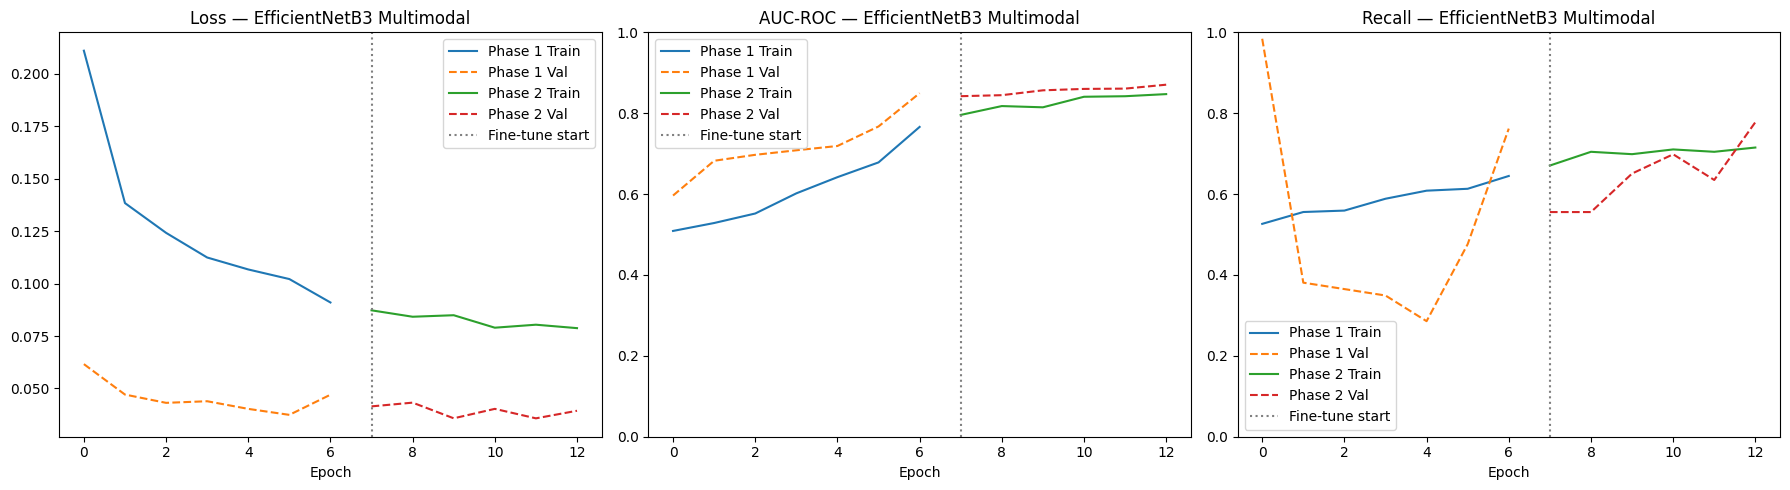

In [46]:
def plot_combined_history(history1, history2=None):
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    # Changed 'accuracy' to 'recall' based on tracked metrics
    metrics = ["loss", "auc", "recall"]
    titles  = ["Loss", "AUC-ROC", "Recall"]

    for i, (ax, metric, title) in enumerate(zip(axes, metrics, titles)):
        # Phase 1
        ax.plot(history1.history[metric],     label="Phase 1 Train")
        ax.plot(history1.history[f"val_{metric}"], label="Phase 1 Val", linestyle="--")

        # Phase 2 (offset epoch index)
        if history2 is not None:
            offset = len(history1.history[metric])
            epochs_p2 = range(offset, offset + len(history2.history[metric]))
            ax.plot(epochs_p2, history2.history[metric], label="Phase 2 Train")
            ax.plot(epochs_p2, history2.history[f"val_{metric}"],
                    label="Phase 2 Val", linestyle="--")
            ax.axvline(x=offset, color="gray", linestyle=":", label="Fine-tune start")

        ax.set_title(f"{title} — EfficientNetB3 Multimodal")
        ax.set_xlabel("Epoch")
        ax.legend()

        # Add y-limit for AUC and Recall
        if metric in ["auc", "recall"]:
            ax.set_ylim([0, 1])

    plt.tight_layout()
    plt.show()

plot_combined_history(history1, history2)


28/28 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step
Đang tìm threshold tối ưu...

── THRESHOLD TUNING KẾT QUẢ ──────────────────────────
Threshold tối ưu   : 0.55  (mặc định 0.50)
Recall Malignant   : 0.6329  ← Tỷ lệ phát hiện ung thư
Precision Malignant: 0.5000  ← Độ chính xác khi dự đoán dương
F1 Malignant       : 0.5587  ← Cân bằng recall + precision
Specificity        : 0.9375  ← Tỷ lệ phát hiện đúng Benign
────────────────────────────────────────────────────────

📌 Gợi ý threshold theo mục tiêu:
   - Tối đa recall (không bỏ sót): threshold ≈ 0.05
   - Cân bằng F1               : threshold ≈ 0.55  ← đang dùng
   - Thử: 0.3, 0.4, 0.5 và so sánh kết quả!


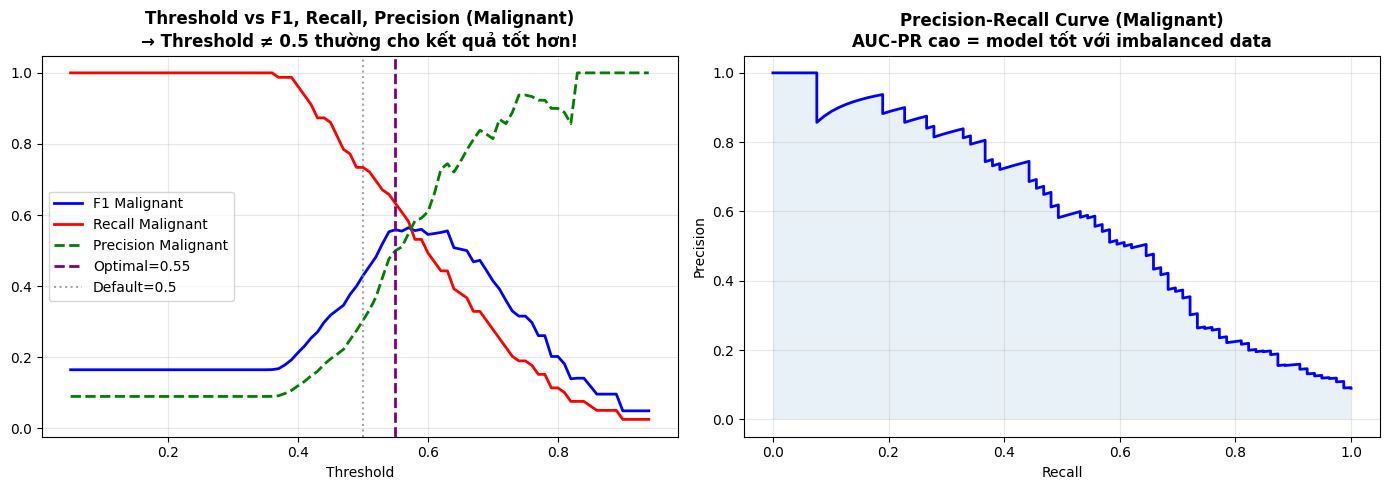


Sử dụng threshold = 0.55

📊 ĐÁNH GIÁ MÔ HÌNH — EfficientNetB3 Multimodal ISIC 2024
  pAUC (TPR≥80%)    : 3.3871  ← Metric chính ISIC 2024
  AUC-ROC           : 0.8598
  Recall Malignant  : 0.6329  ← Tỷ lệ phát hiện ung thư
  F1 Malignant      : 0.5587  ← Cân bằng recall + precision
  Precision Malignant: 0.5000  ← Tránh false alarm
  F1 Macro          : 0.7543
  Threshold         : 0.55
  ✗ Accuracy        : (không hiển thị — vô nghĩa với imbalanced data)

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.96      0.94      0.95       800
Malignant (1)       0.50      0.63      0.56        79

     accuracy                           0.91       879
    macro avg       0.73      0.79      0.75       879
 weighted avg       0.92      0.91      0.91       879



/tmp/ipykernel_1297/544504158.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pauc_score = np.trapz(tpr[mask], fpr[mask]) / (1.0 - min_tpr)
/tmp/ipykernel_1297/544504158.py:240: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


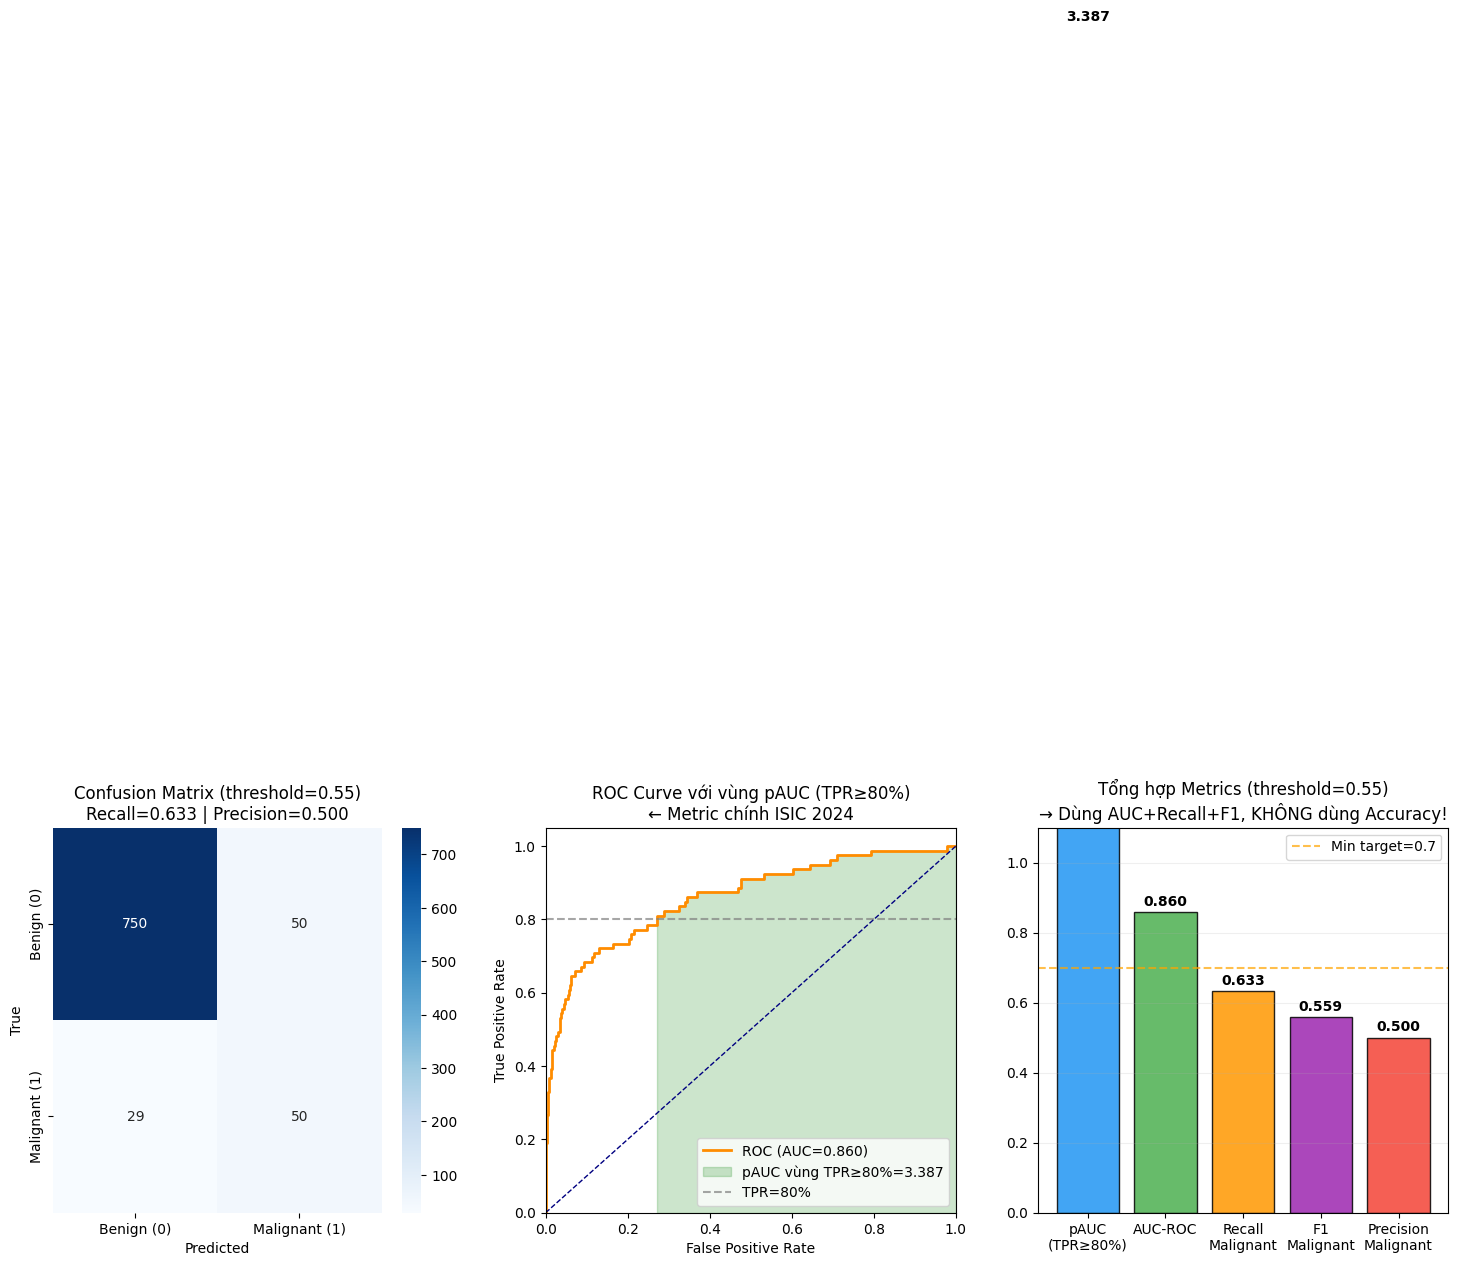


📌 Threshold tối ưu để dùng lại: 0.55
Gợi ý: Giảm threshold xuống 0.2-0.3 nếu cần tăng Recall Malignant cao hơn


In [48]:
# Đánh giá mô hình trên tập test với Threshold Tuning tự động
# CẢI TIẾN: auto_tune_threshold=True sẽ tìm threshold tối ưu cho Malignant
f1_mal, auc_score, optimal_threshold, pauc_score = evaluate_model(
    model, X_tab_test, X_img_test, y_test, label_encoder,
    auto_tune_threshold=True   # Tắt bằng False nếu muốn dùng threshold=0.5
)

print(f"\n📌 Threshold tối ưu để dùng lại: {optimal_threshold:.2f}")
print("Gợi ý: Giảm threshold xuống 0.2-0.3 nếu cần tăng Recall Malignant cao hơn")

In [49]:
# ============================================================
# PHAN 5: XAI - GIAI THICH MO HINH (Explainable AI)
# Theo kien truc trong bao cao ky thuat MLOps:
#   - XRAI heatmap cho nhanh anh (su dung GradCAM wrapper)
#   - SHAP waterfall cho nhanh metadata
#   - MultimodalXAIRunner: chay ca 2 trong 1 lan goi
# Ref: Bao cao muc 5.1 (xrai_explainer.py), 5.2 (shap_explainer.py), 5.3
# ============================================================

!pip install shap grad-cam -q
# De dung XRAI thuc su (Google Research saliency library):
!pip install saliency -qS


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 109.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 70.1 MB/s eta 0:00:00

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -S


In [50]:
# ============================================================
# 5.1 GRAD-CAM / XRAI (IMAGE EXPLAINER)
# ============================================================

class GradCAMExplainer:
    def __init__(self, model, last_conv_layer_name):
        self.model = model
        self.last_conv_layer = model.get_layer(last_conv_layer_name)

        # Model phụ để lấy feature map + output
        self.grad_model = tf.keras.models.Model(
            inputs=model.inputs,
            outputs=[self.last_conv_layer.output, model.output]
        )

    def compute_heatmap(self, image, tabular, class_idx=None):
        """
        image: (1, H, W, 3)
        tabular: (1, num_features)
        """

        with tf.GradientTape() as tape:
            # Corrected input order: image first, then tabular
            conv_outputs, predictions = self.grad_model([image, tabular])

            if class_idx is None:
                class_idx = tf.argmax(predictions[0])

            loss = predictions[:, class_idx]

        grads = tape.gradient(loss, conv_outputs)

        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]

        heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

        # Normalize
        heatmap = tf.maximum(heatmap, 0)
        heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

        return heatmap.numpy()

    def overlay_heatmap(self, heatmap, image, alpha=0.4):
        """
        Overlay heatmap lên ảnh gốc
        """

        heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        overlay = cv2.addWeighted(image.astype(np.uint8), 1 - alpha, heatmap, alpha, 0)
        return overlay

In [51]:
import shap

class SHAPMetadataExplainer:
    def __init__(self, model, background_tabular, background_image, feature_names):
        print("Initializing SHAP Explainer...")

        self.feature_names = feature_names

        # ===== FIX background image shape =====
        if len(background_image.shape) == 3:
            background_image = np.expand_dims(background_image, axis=0)

        background_image = tf.convert_to_tensor(background_image, dtype=tf.float32)

        # ===== Input =====
        tabular_input = tf.keras.Input(shape=background_tabular.shape[1:])

        # ===== Safe shape extraction =====
        H, W, C = background_image.shape[-3:]

        def tile_image(x):
            batch_size = tf.shape(x)[0]
            return tf.tile(background_image, [batch_size, 1, 1, 1])

        img_tiled = tf.keras.layers.Lambda(
            tile_image,
            output_shape=(H, W, C)
        )(tabular_input)

        # ===== Forward =====
        output = model({
            'image_input': img_tiled,
            'tabular_input': tabular_input
        })

        self.wrapper_model = tf.keras.Model(
            inputs=tabular_input,
            outputs=output
        )

        # ===== SHAP =====
        self.explainer = shap.DeepExplainer(
            self.wrapper_model,
            background_tabular
        )

    def explain(self, X):
        return self.explainer.shap_values(X)

In [52]:
class MultimodalXAIRunner:
    def __init__(self,
                 model,
                 background_tabular,
                 background_image,
                 feature_names,
                 last_conv_layer):

        print("Initializing Multimodal XAI Runner...")

        self.model = model
        self.feature_names = feature_names

        # SHAP
        self.shap_explainer = SHAPMetadataExplainer(
            model,
            background_tabular,
            background_image,
            feature_names
        )

        # Grad-CAM
        self.gradcam = GradCAMExplainer(model, last_conv_layer)

        print("XAI Ready!")

    def explain(self, tabular_sample, image_sample, visualize=True):
        """
        tabular_sample: (num_features,)
        image_sample: (H, W, 3)
        """

        tabular_sample_expanded = np.expand_dims(tabular_sample, axis=0) # Rename to avoid conflict
        image_sample_expanded = np.expand_dims(image_sample, axis=0)

        # ===== SHAP =====
        shap_values = self.shap_explainer.explain(tabular_sample_expanded)

        # ===== Grad-CAM =====
        heatmap = self.gradcam.compute_heatmap(image_sample_expanded, tabular_sample_expanded)

        results = {
            "shap_values": shap_values,
            "heatmap": heatmap
        }

        if visualize:
            # Pass the full shap_values array, not shap_values[0]
            self.visualize_results(image_sample, heatmap, shap_values, tabular_sample) # Pass original samples for visualization

        return results

    def visualize_results(self, image, heatmap, shap_values, tabular_sample):
        """
        Hiển thị cả image + SHAP
        """

        overlay = self.gradcam.overlay_heatmap(heatmap, image)

        # Create a figure for both plots
        fig = plt.figure(figsize=(15, 6))

        # --- Grad-CAM Plot ---
        ax1 = fig.add_subplot(1, 2, 1)
        ax1.imshow(overlay)
        ax1.set_title("Grad-CAM")
        ax1.axis("off")

        # --- SHAP Waterfall Plot for Tabular Data ---
        ax2 = fig.add_subplot(1, 2, 2) # Create subplot for SHAP

        # Get the expected value from the explainer (handle TensorFlow and NumPy scalars)
        expected_value = self.shap_explainer.explainer.expected_value
        if tf.is_tensor(expected_value):
            expected_value = expected_value.numpy().item()
        elif isinstance(expected_value, np.ndarray):
            expected_value = expected_value.item()
        # else: it's already a Python scalar

        # Extract SHAP values and data for a single instance explanation
        # For a single-output model, shap_values is typically [array(1, num_features)]
        # We need shap_values[0][0] which is (num_features,)
        shap_values_single_instance = shap_values[0][0]
        # tabular_sample is already (num_features,) as passed from explain method

        # Create a shap.Explanation object
        expl = shap.Explanation(
            values=shap_values_single_instance,
            base_values=expected_value,
            data=tabular_sample, # Use the original (num_features,) sample
            feature_names=self.feature_names
        )

        # Plot using waterfall plot directly onto the axis, then set title
        # Removed show=False as shap.plots.waterfall does not accept it
        shap.plots.waterfall(expl, max_display=10)
        ax2.set_title("SHAP Waterfall Plot for Tabular Data") # Title for the subplot

        plt.tight_layout()
        plt.show()


Initializing Multimodal XAI Runner...
Initializing SHAP Explainer...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_405
Received: inputs=['Tensor(shape=(100, 37))']
  warnings.warn(msg)


XAI Ready!


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_405
Received: inputs=['Tensor(shape=(200, 37))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_405
Received: inputs=['Tensor(shape=(1, 37))']
  warnings.warn(msg)


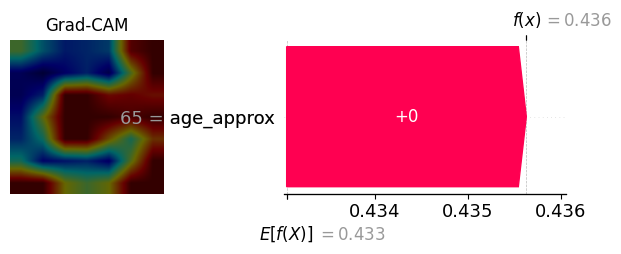

<Figure size 640x480 with 0 Axes>

In [53]:
import numpy as np

# Define background_tabular and background_image for XAI explainers
# Using a small subset of training data for background reference
background_tabular_samples = 100 # Adjust as needed for performance vs accuracy trade-off
background_tabular = X_tab_train[np.random.choice(X_tab_train.shape[0], background_tabular_samples, replace=False)]
background_image = X_img_train[0] # Use a single representative image

# Recreate the full list of tabular columns used during model training
label_col = 'target'
id_col = 'isic_id'

exclude_cols = [label_col, id_col, 'patient_id', 'attribution', 'copyright_license',
                'image_type', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4',
                'iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'lesion_id']

# Get numeric columns from df_subset (the filtered DataFrame used for X_tabular creation)
numeric_cols_from_subset = df_subset.select_dtypes(include=np.number).columns.tolist()
full_tabular_columns = [col for col in numeric_cols_from_subset if col not in exclude_cols]

# Add categorical columns that were encoded and used in X_tabular
cat_cols_for_tabular = ['sex', 'anatom_site_general']
for col in cat_cols_for_tabular:
    # Only add if not already present and is a column in the original df_subset
    if col in df_subset.columns and col not in full_tabular_columns:
        full_tabular_columns.append(col)

# Define feature_names from the list of tabular columns used in data preparation
feature_names = full_tabular_columns

xai_runner = MultimodalXAIRunner(
    model=model,
    background_tabular=background_tabular,
    background_image=background_image,
    feature_names=feature_names,
    last_conv_layer=last_conv
)

result = xai_runner.explain(
    X_tab_train[0],
    X_img_train[0]
)

Đang giải thích mẫu index: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Prediction: [[0.4050919]]
Predicted class: 0 | Confidence: 0.4051


/tmp/ipykernel_1297/1770149541.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_class = int(prediction[0] > 0.5)
/tmp/ipykernel_1297/1770149541.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  confidence = float(prediction[0])
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_405
Received: inputs=['Tensor(shape=(1, 37))']
  warnings.warn(msg)


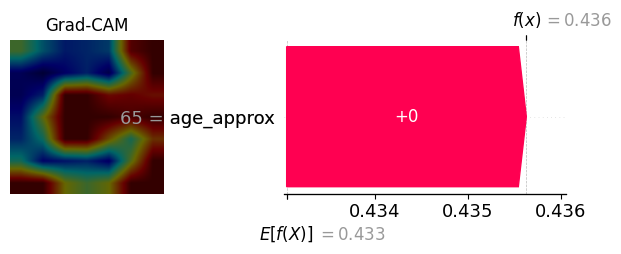

<Figure size 640x480 with 0 Axes>

XAI hoàn tất!


In [54]:
# ===== Chọn 1 mẫu từ tập train/test =====
sample_idx = 0   # bạn có thể đổi index

tab_sample = X_tab_train[sample_idx]
img_sample = X_img_train[sample_idx]

print(f"Đang giải thích mẫu index: {sample_idx}")

# ===== Dự đoán model =====
tab_input = np.expand_dims(tab_sample, axis=0)
img_input = np.expand_dims(img_sample, axis=0)

prediction = model.predict({
    'image_input': img_input,
    'tabular_input': tab_input
})

print("Prediction:", prediction)

# Nếu là binary classification
if prediction.shape[-1] == 1:
    pred_class = int(prediction[0] > 0.5)
    confidence = float(prediction[0])
else:
    pred_class = int(np.argmax(prediction[0]))
    confidence = float(np.max(prediction[0]))

print(f"Predicted class: {pred_class} | Confidence: {confidence:.4f}")


# ===== Chạy XAI =====
result = xai_runner.explain(
    tab_sample,
    img_sample,
    visualize=True   # bật hiển thị
)

print("XAI hoàn tất!")

In [55]:
#Hiển thị top feature SHAP
shap_values = result["shap_values"][0][0]

# Lấy top 10 feature quan trọng nhất
importance = np.abs(shap_values)
top_idx = np.argsort(importance)[-10:][::-1]

print("\nTop 10 features quan trọng:")
for i in top_idx:
    print(f"{feature_names[i]}: {shap_values[i]:.4f}")


Top 10 features quan trọng:
age_approx: 0.0026


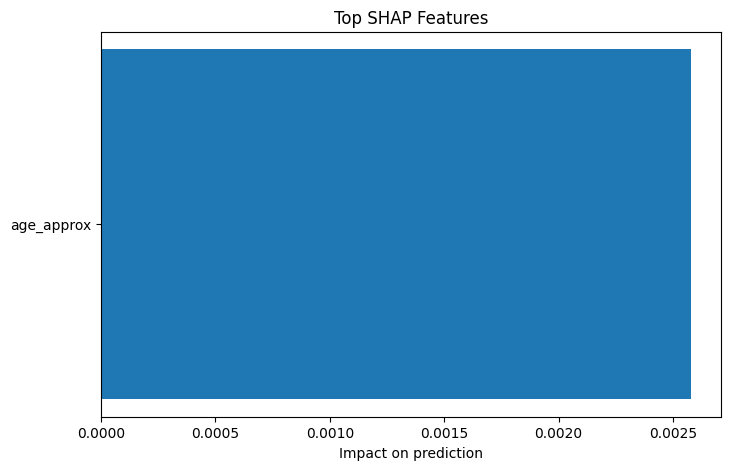

In [56]:
#Vẽ biểu đồ SHAP đẹp hơn
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

values = shap_values[top_idx]
names = [feature_names[i] for i in top_idx]

plt.barh(names, values)
plt.gca().invert_yaxis()
plt.title("Top SHAP Features")
plt.xlabel("Impact on prediction")

plt.show()

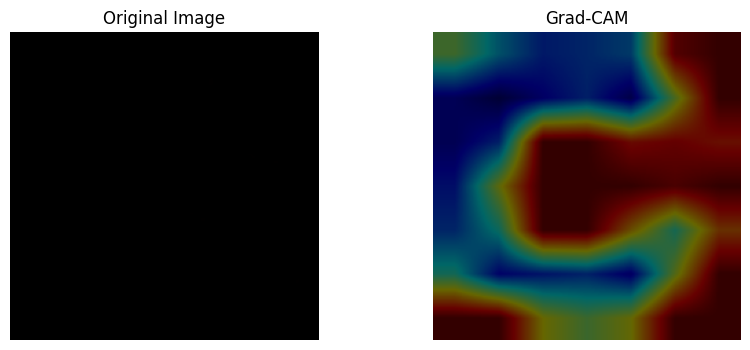

In [57]:
#Hiển thị ảnh gốc + heatmap rõ hơn
heatmap = result["heatmap"]

overlay = xai_runner.gradcam.overlay_heatmap(heatmap, img_sample)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_sample.astype(np.uint8))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(overlay)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

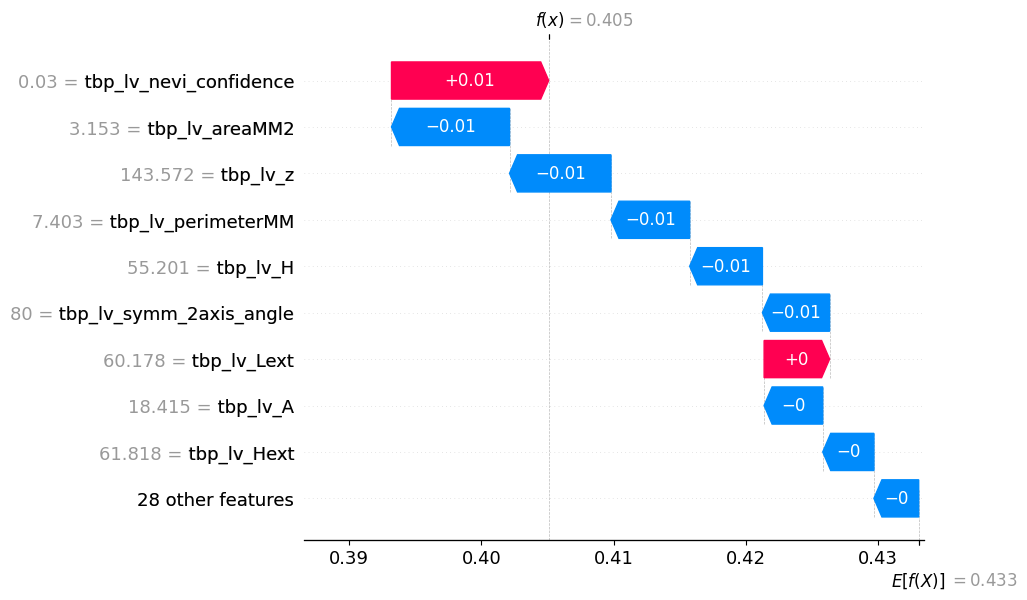

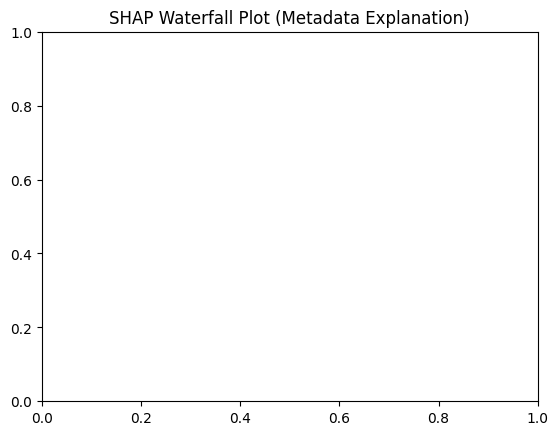

In [58]:
#==========================================================
#5.6 SHAP WATERFALL PLOT CHI TIẾT (METADATA)
#==============================================
# ===== Lấy SHAP values từ kết quả =====
shap_values = result["shap_values"]

# Expected value from explainer.
# It can be a TensorFlow scalar tensor, which needs to be converted to a NumPy scalar.
expected_value = xai_runner.shap_explainer.explainer.expected_value
if tf.is_tensor(expected_value):
    expected_value = expected_value.numpy()
elif isinstance(expected_value, np.ndarray) and expected_value.ndim == 0:
    # Handle numpy 0-d array scalar
    expected_value = expected_value.item()
elif isinstance(expected_value, np.ndarray) and expected_value.ndim == 1 and expected_value.shape[0] == 1:
    # Handle numpy 1-d array with single element
    expected_value = expected_value[0]


# Tuỳ bài toán: binary hoặc multi-class
if isinstance(shap_values, list):
    # DeepExplainer for single output model (like sigmoid) often returns a list with one element:
    # [array(num_samples, num_features)]
    # For a single sample, shap_values[0] would be array(1, num_features)
    # So shap_val_sample needs to be shap_values[0][0]
    if len(shap_values) == 1 and len(shap_values[0].shape) == 2 and shap_values[0].shape[0] == 1:
        shap_val_sample = shap_values[0][0] # shape (num_features,)
    else:
        # Fallback for unexpected shapes, flatten to be safe
        shap_val_sample = np.asarray(shap_values).flatten()
else:
    # shap_values is a numpy array directly, likely (1, num_features, 1) from TF model
    # shap_values[0] will be (num_features, 1)
    # We need to flatten it to (num_features,)
    shap_val_sample = shap_values[0].flatten()


# ===== Tạo SHAP Explanation object (chuẩn mới) =====
expl = shap.Explanation(
    values=shap_val_sample,
    base_values=expected_value, # This should now be a numpy scalar or Python float
    data=X_tab_train[0], # data for a single instance should be 1D
    feature_names=feature_names
)

# ===== Vẽ Waterfall Plot =====
plt.figure(figsize=(10, 6))
shap.plots.waterfall(expl, max_display=10)
plt.title("SHAP Waterfall Plot (Metadata Explanation)")
plt.show()

In [59]:
#In ra giải thích dạng text (giống báo cáo)
print("\n=== GIAI THICH CHI TIET ===")

for i in np.argsort(np.abs(shap_val_sample))[::-1][:10]:
    impact = shap_val_sample[i]
    name = feature_names[i]

    if impact > 0:
        direction = "TANG nguy co"
    else:
        direction = "GIAM nguy co"

    print(f"{name}: {impact:.4f} -> {direction}")


=== GIAI THICH CHI TIET ===
tbp_lv_nevi_confidence: 0.0119 -> TANG nguy co
tbp_lv_areaMM2: -0.0089 -> GIAM nguy co
tbp_lv_z: -0.0077 -> GIAM nguy co
tbp_lv_perimeterMM: -0.0059 -> GIAM nguy co
tbp_lv_H: -0.0055 -> GIAM nguy co
tbp_lv_symm_2axis_angle: -0.0051 -> GIAM nguy co
tbp_lv_Lext: 0.0049 -> TANG nguy co
tbp_lv_A: -0.0044 -> GIAM nguy co
tbp_lv_Hext: -0.0039 -> GIAM nguy co
tbp_lv_x: 0.0037 -> TANG nguy co


In [60]:
#Tự động tạo câu giải thích giống paper
explanations = []

for i in np.argsort(np.abs(shap_val_sample))[::-1][:5]:
    name = feature_names[i]
    value = X_tab_train[0][i]
    impact = shap_val_sample[i]

    if impact > 0:
        explanations.append(f"{name} = {value} lam tang nguy co")
    else:
        explanations.append(f"{name} = {value} lam giam nguy co")

print("\nMo ta tu dong:")
print(" + ".join(explanations))


Mo ta tu dong:
tbp_lv_nevi_confidence = 0.030359966680407524 lam tang nguy co + tbp_lv_areaMM2 = 3.1525614261627197 lam giam nguy co + tbp_lv_z = 143.572265625 lam giam nguy co + tbp_lv_perimeterMM = 7.402963161468506 lam giam nguy co + tbp_lv_H = 55.20131301879883 lam giam nguy co


Đang tính SHAP trên 50 samples...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_405
Received: inputs=['Tensor(shape=(50, 37))']
  warnings.warn(msg)


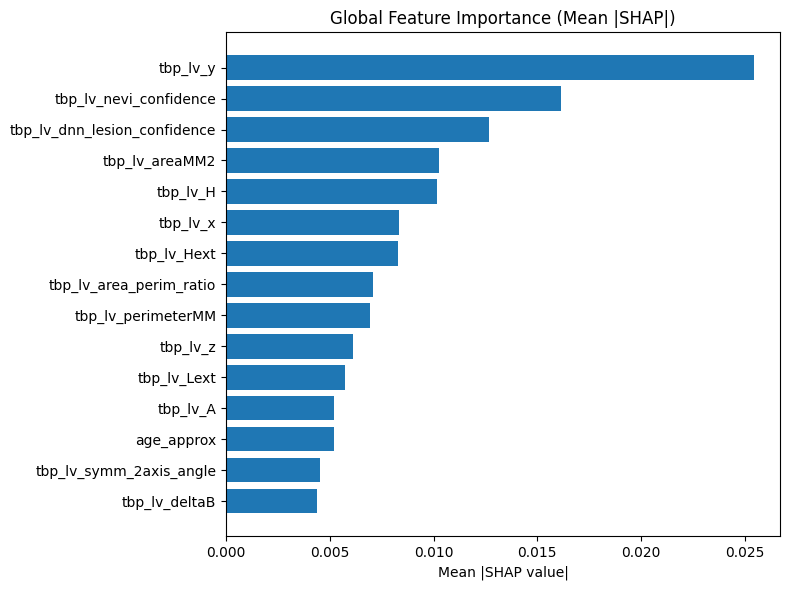

In [61]:
#============================================================
#5.7 SHAP BAR SUMMARY (GLOBAL IMPORTANCE)
#===================================
# ===== Chọn tập dữ liệu để phân tích (test hoặc validation) =====
#  Nên lấy 50–200 samples để tránh SHAP quá chậm
N_SAMPLES = min(50, len(X_tab_train))

indices = np.random.choice(len(X_tab_train), N_SAMPLES, replace=False)
X_sample = X_tab_train[indices]

print(f"Đang tính SHAP trên {N_SAMPLES} samples...")

# ===== Tính SHAP values =====
shap_values = xai_runner.shap_explainer.explain(X_sample)

# ===== Xử lý output (binary vs multi-class) =====
if isinstance(shap_values, list):
    # For single-output models, shap_values is a list of one (N, F, 1) array
    shap_vals = shap_values[0]
else:
    # Fallback if shap_values is already an array, although less likely for DeepExplainer
    shap_vals = shap_values

# ===== Tính Mean |SHAP| =====
# Ensure shap_vals is correctly shaped for mean calculation
# If shap_vals is (N_SAMPLES, num_features, 1), mean over axis 0 results in (num_features, 1)
mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)

# ===== Sắp xếp feature theo độ quan trọng =====
# Squeeze mean_abs_shap to make it 1D before argsort
sorted_idx = np.argsort(mean_abs_shap.squeeze())[::-1]

top_k = 15
top_idx = sorted_idx[:top_k]

top_features = [feature_names[i] for i in top_idx]
top_values = mean_abs_shap[top_idx].squeeze() # Also squeeze top_values for consistent dimensionality

# ===== Vẽ biểu đồ Bar =====
plt.figure(figsize=(8, 6))

plt.barh(top_features, top_values)
plt.gca().invert_yaxis()

plt.title("Global Feature Importance (Mean |SHAP|)")
plt.xlabel("Mean |SHAP value|")

plt.tight_layout()
plt.show()

Selected samples: [np.int64(6), np.int64(23), np.int64(0)]


/tmp/ipykernel_1297/1542046665.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cls = int(pred[0] > 0.5)
/tmp/ipykernel_1297/1542046665.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  conf = float(pred[0])


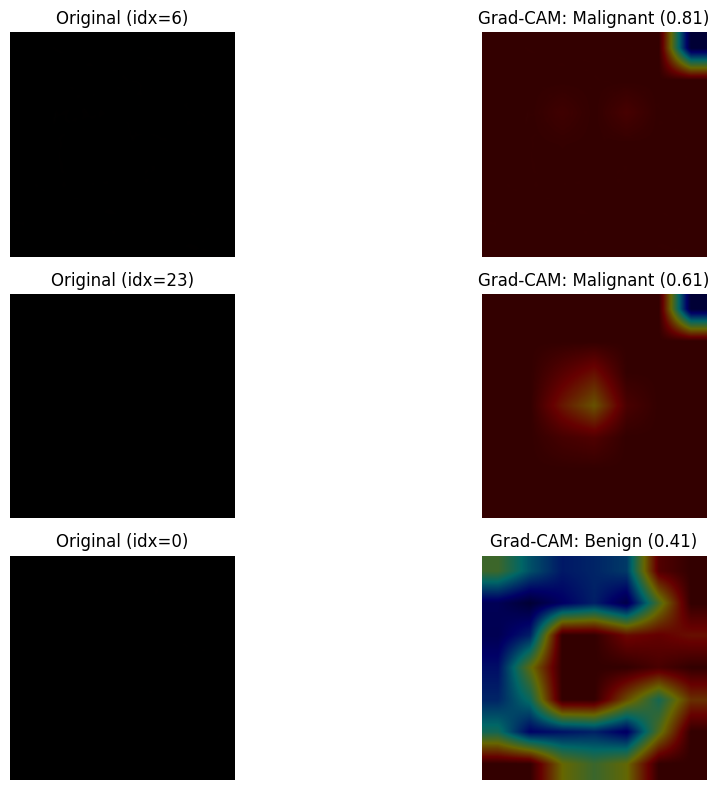

In [62]:
#============================================================
#5.8 SO SÁNH GRAD-CAM TRÊN 3 MẪU (MALIGNANT vs BENIGN)
#===========================================
# ===== Hàm lấy prediction + class =====
def predict_sample(model, tab, img):
    tab = np.expand_dims(tab, axis=0)
    img = np.expand_dims(img, axis=0)

    pred = model.predict({
        'image_input': img,
        'tabular_input': tab
    }, verbose=0)

    if pred.shape[-1] == 1:
        cls = int(pred[0] > 0.5)
        conf = float(pred[0])
    else:
        cls = int(np.argmax(pred[0]))
        conf = float(np.max(pred[0]))

    return cls, conf


# ===== Chọn 3 mẫu: 2 malignant + 1 benign (ví dụ) =====
malignant_indices = np.where(y_train == 1)[0]
benign_indices    = np.where(y_train == 0)[0]

idx_1 = malignant_indices[0]
idx_2 = malignant_indices[1]
idx_3 = benign_indices[0]

sample_indices = [idx_1, idx_2, idx_3]

print("Selected samples:", sample_indices)


# ===== Vẽ so sánh =====
plt.figure(figsize=(12, 8))

for i, idx in enumerate(sample_indices):
    tab = X_tab_train[idx]
    img = X_img_train[idx]

    # Predict
    pred_class, conf = predict_sample(model, tab, img)

    # Grad-CAM
    tab_input = np.expand_dims(tab, axis=0)
    img_input = np.expand_dims(img, axis=0)

    heatmap = xai_runner.gradcam.compute_heatmap(img_input, tab_input)
    overlay = xai_runner.gradcam.overlay_heatmap(heatmap, img)

    # ===== Plot =====
    plt.subplot(3, 2, i*2 + 1)
    plt.imshow(img.astype(np.uint8))
    plt.title(f"Original (idx={idx})")
    plt.axis("off")

    plt.subplot(3, 2, i*2 + 2)
    plt.imshow(overlay)
    label_name = "Malignant" if pred_class == 1 else "Benign"
    plt.title(f"Grad-CAM: {label_name} ({conf:.2f})")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [65]:
from sklearn.model_selection import train_test_split

# Chia dữ liệu thành train+val (80%) và test (20%)
# stratify=y đảm bảo tỷ lệ benign/malignant đồng đều giữa các tập
X_img_trainval, X_img_test, X_tab_trainval, X_tab_test, y_trainval, y_test = train_test_split(
    X_image, X_tabular, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train+Validation set: Image shape {X_img_trainval.shape}, Tabular shape {X_tab_trainval.shape}, Labels {len(y_trainval)}")
print(f"  - Benign: {np.sum(y_trainval==0)}, Malignant: {np.sum(y_trainval==1)}")
print(f"Test set: Image shape {X_img_test.shape}, Tabular shape {X_tab_test.shape}, Labels {len(y_test)}")
print(f"  - Benign: {np.sum(y_test==0)}, Malignant: {np.sum(y_test==1)}")

Train+Validation set: Image shape (3514, 224, 224, 3), Tabular shape (3514, 37), Labels 3514
  - Benign: 3200, Malignant: 314
Test set: Image shape (879, 224, 224, 3), Tabular shape (879, 37), Labels 879
  - Benign: 800, Malignant: 79


In [66]:
def predict_skin_lesion(model, csv_data, image_path, tabular_columns, encoders=None):
    """
    Dự đoán khả năng ác tính (malignant) của tổn thương da - ISIC 2024 (Binary)

    Args:
        model: Mô hình đã huấn luyện
        csv_data: Đường dẫn CSV hoặc DataFrame metadata
        image_path: Đường dẫn ảnh
        tabular_columns: Danh sách cột đặc trưng dùng trong huấn luyện
        encoders: Dict các LabelEncoder cho cột phân loại

    Returns:
        dict chứa kết quả dự đoán
    """
    import pandas as pd
    import numpy as np
    import tensorflow as tf
    from PIL import Image

    # Load DataFrame
    if isinstance(csv_data, str):
        df = pd.read_csv(csv_data)
    else:
        df = csv_data

    # Lấy mẫu đầu tiên
    sample = df.iloc[0][tabular_columns].copy()

    # Tiền xử lý boolean
    bool_map = {"TRUE": 1, "FALSE": 0, "True": 1, "False": 0}
    for col in sample.index:
        val = sample[col]
        if isinstance(val, str) and val.strip().upper() in bool_map:
            sample[col] = bool_map[val.strip().upper()]

    # Mã hóa cột phân loại
    if encoders:
        for col in encoders:
            if col in sample and not pd.isna(sample[col]):
                sample[col] = encoders[col].transform([str(sample[col])])[0]

    # Điền NaN
    sample = sample.fillna(0)

    try:
        sample = sample.astype('float32')
    except Exception as e:
        print("[LỖI] Không thể ép kiểu float:", e)
        return None

    tabular_input = tf.constant(sample.values, dtype=tf.float32)[tf.newaxis, ...]

    # Load và tiền xử lý ảnh
    img_array = load_image(image_path, target_size=(224, 224))
    if img_array is None:
        print(f"[LỖI] Không thể tải ảnh: {image_path}")
        return None

    img_processed = preprocess_image(img_array)
    if img_processed is None:
        print(f"[LỖI] Lỗi tiền xử lý ảnh")
        return None

    image_input = tf.constant(img_processed, dtype=tf.float32)[tf.newaxis, ...]

    # Dự đoán
    prediction = model.predict({'image_input': image_input, 'tabular_input': tabular_input})

    # Xử lý output binary (sigmoid)
    if prediction.shape[-1] == 1:
        prob_malignant = float(prediction[0][0])
        prob_benign = 1.0 - prob_malignant
        predicted_class = 1 if prob_malignant > 0.5 else 0
        label = 'Malignant (Ác tính)' if predicted_class == 1 else 'Benign (Lành tính)'
        confidence = prob_malignant * 100 if predicted_class == 1 else prob_benign * 100
    else:
        prob_benign = float(prediction[0][0])
        prob_malignant = float(prediction[0][1])
        predicted_class = np.argmax(prediction[0])
        label = 'Malignant (Ác tính)' if predicted_class == 1 else 'Benign (Lành tính)'
        confidence = max(prob_benign, prob_malignant) * 100

    return {
        'diagnosis': label,
        'predicted_class': predicted_class,
        'confidence': confidence,
        'probabilities': {
            'Benign (0)': prob_benign * 100,
            'Malignant (1)': prob_malignant * 100
        }
    }

In [67]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Dự đoán với ISIC 2024 metadata
csv_path = '/content/train-metadata.csv'

# Chọn một ảnh mẫu từ thư mục đã trích xuất
sample_image_name = image_files[0]  # Lấy ảnh đầu tiên trong thư mục
image_path = os.path.join(image_folder, sample_image_name)

# Recreate the full list of tabular columns used during model training
# This logic is extracted from `prepare_multimodal_data` function in cell_31
label_col = 'target'
id_col = 'isic_id'

exclude_cols = [label_col, id_col, 'patient_id', 'attribution', 'copyright_license',
                'image_type', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4',
                'iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'lesion_id']

# Get numeric columns from df_subset (the filtered DataFrame used for X_tabular creation)
numeric_cols_from_subset = df_subset.select_dtypes(include=np.number).columns.tolist()
full_tabular_columns = [col for col in numeric_cols_from_subset if col not in exclude_cols]

# Add categorical columns that were encoded and used in X_tabular
cat_cols_for_tabular = ['sex', 'anatom_site_general']
for col in cat_cols_for_tabular:
    # Only add if not already present and is a column in the original df_subset
    if col in df_subset.columns and col not in full_tabular_columns:
        full_tabular_columns.append(col)

tabular_columns = full_tabular_columns

# Fit encoders for categorical columns using the df_subset (the filtered DataFrame used for training)
encoders = {}
for col in ['sex', 'anatom_site_general']:
    if col in df_subset.columns:
        le = LabelEncoder()
        # Ensure the column is treated as string for fitting
        le.fit(df_subset[col].astype(str))
        encoders[col] = le

# Dự đoán
# Pass df_subset instead of csv_path to ensure consistency with training data processing
result = predict_skin_lesion(model, df_subset, image_path, tabular_columns, encoders=encoders)
if result:
    print("\nKết quả dự đoán ISIC 2024:")
    print(f"Chẩn đoán: {result['diagnosis']}")
    print(f"Độ tin cậy: {result['confidence']:.2f}%")
    print(f"Xác suất Benign: {result['probabilities']['Benign (0)']:.2f}%")
    print(f"Xác suất Malignant: {result['probabilities']['Malignant (1)']:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

Kết quả dự đoán ISIC 2024:
Chẩn đoán: Malignant (Ác tính)
Độ tin cậy: 56.00%
Xác suất Benign: 44.00%
Xác suất Malignant: 56.00%


/tmp/ipykernel_1297/1921891425.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.fillna(0)


In [68]:
from sklearn.preprocessing import LabelEncoder

df_meta = pd.read_csv(csv_path)

# Fit encoders cho các cột phân loại của ISIC 2024
encoders = {}
for col in ['sex', 'anatom_site_general']:
    if col in df_meta.columns:
        le = LabelEncoder()
        df_meta[col] = df_meta[col].astype(str)
        le.fit(df_meta[col])
        encoders[col] = le

# Gọi hàm dự đoán với encoders
result = predict_skin_lesion(
    model,
    csv_path,
    image_path,
    tabular_columns,
    encoders=encoders
)
if result:
    print("Chẩn đoán:", result['diagnosis'])

/tmp/ipykernel_1297/3325594246.py:3: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta = pd.read_csv(csv_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


/tmp/ipykernel_1297/1921891425.py:22: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_data)
/tmp/ipykernel_1297/1921891425.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.fillna(0)


Chẩn đoán: Benign (Lành tính)


In [69]:
# Dự đoán cho một bệnh nhân mẫu từ ISIC 2024 metadata
df_meta = pd.read_csv(csv_path)

# Lọc các dòng có ảnh đã trích xuất
available_ids = set([os.path.splitext(f)[0] for f in image_files])
df_available = df_meta[df_meta['isic_id'].isin(available_ids)].reset_index(drop=True)

sample_row = df_available.iloc[1]  # Chọn dòng thứ 2
new_patient = sample_row.to_dict()

patient_image_path = os.path.join(image_folder, new_patient['isic_id'] + '.jpg')

# Recreate the full list of tabular columns and encoders, consistent with training
label_col = 'target'
id_col = 'isic_id'

exclude_cols = [label_col, id_col, 'patient_id', 'attribution', 'copyright_license',
                'image_type', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4',
                'iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'lesion_id']

numeric_cols_from_subset = df_subset.select_dtypes(include=np.number).columns.tolist()
full_tabular_columns = [col for col in numeric_cols_from_subset if col not in exclude_cols]

cat_cols_for_tabular = ['sex', 'anatom_site_general']
for col in cat_cols_for_tabular:
    if col in df_subset.columns and col not in full_tabular_columns:
        full_tabular_columns.append(col)

tabular_columns = full_tabular_columns

encoders = {}
for col in ['sex', 'anatom_site_general']:
    if col in df_subset.columns:
        le = LabelEncoder()
        le.fit(df_subset[col].astype(str))
        encoders[col] = le

# Dự đoán
diagnosis_result = predict_skin_lesion(model, df_available, patient_image_path, tabular_columns, encoders=encoders)

if diagnosis_result:
    print(f"ISIC ID: {new_patient['isic_id']}")
    print(f"Nhãn thực tế (target): {new_patient.get('target', 'N/A')} (0=Benign, 1=Malignant)")
    print(f"Diagnosis: {diagnosis_result['diagnosis']}")
    print(f"Confidence: {diagnosis_result['confidence']:.2f}%")
    print("Probabilities:")
    for class_name, prob in diagnosis_result['probabilities'].items():
        print(f"  {class_name}: {prob:.2f}%")

/tmp/ipykernel_1297/682980367.py:2: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta = pd.read_csv(csv_path)
/tmp/ipykernel_1297/1921891425.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.fillna(0)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
ISIC ID: ISIC_0082829
Nhãn thực tế (target): 1 (0=Benign, 1=Malignant)
Diagnosis: Malignant (Ác tính)
Confidence: 55.80%
Probabilities:
  Benign (0): 44.20%
  Malignant (1): 55.80%


In [70]:
# Trực quan hóa kết quả dự đoán ISIC 2024
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def visualize_prediction(image_path, prediction_result, heatmap=None):
    """
    Hiển thị ảnh da liễu kèm theo kết quả dự đoán ISIC 2024 (Binary).

    Args:
        image_path (str): Đường dẫn ảnh.
        prediction_result (dict): Kết quả từ hàm predict_skin_lesion.
        heatmap (ndarray): Mảng 2D heatmap (tùy chọn).
    """
    image = Image.open(image_path).convert("RGB")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Ảnh gốc với chẩn đoán
    axes[0].imshow(image)
    axes[0].axis('off')
    diagnosis = prediction_result['diagnosis']
    confidence = prediction_result['confidence']
    color = 'red' if 'Malignant' in diagnosis else 'green'
    axes[0].set_title(f"{diagnosis}\nĐộ tin cậy: {confidence:.2f}%",
                      fontsize=14, color=color, fontweight='bold')

    # Nếu có heatmap
    if heatmap is not None:
        heatmap_resized = np.array(Image.fromarray((heatmap * 255).astype(np.uint8)).resize(image.size))
        axes[0].imshow(heatmap_resized, cmap='jet', alpha=0.4)

    # Biểu đồ xác suất
    probs = prediction_result['probabilities']
    classes = list(probs.keys())
    values = list(probs.values())
    colors = ['steelblue' if 'Benign' in c else 'tomato' for c in classes]

    bars = axes[1].bar(classes, values, color=colors, edgecolor='black')
    axes[1].set_title('Xác suất dự đoán', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Xác suất (%)')
    axes[1].set_ylim(0, 100)
    for bar, val in zip(bars, values):
        axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                    f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1297/1111254182.py:7: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df_metadata = pd.read_csv('/content/train-metadata.csv')
/tmp/ipykernel_1297/1921891425.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.fillna(0)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


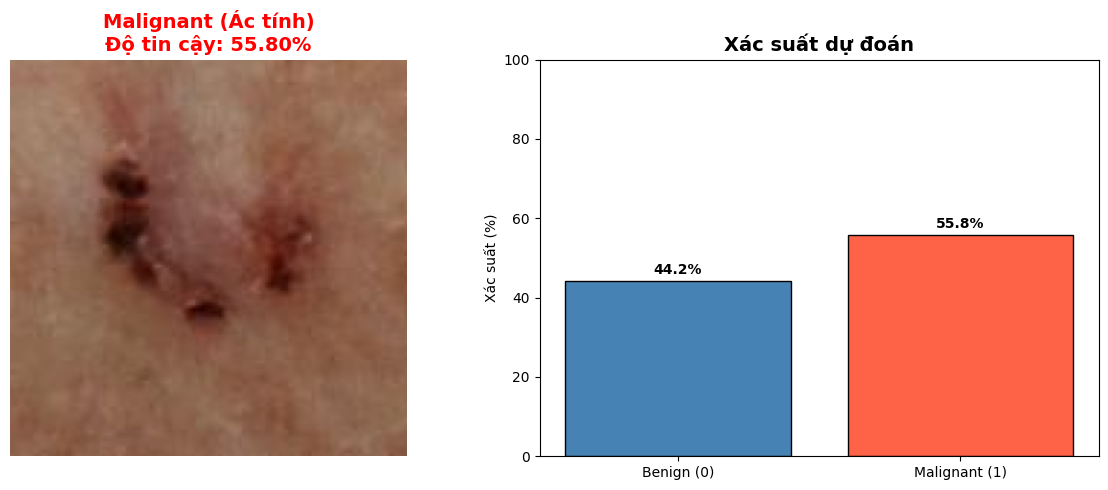

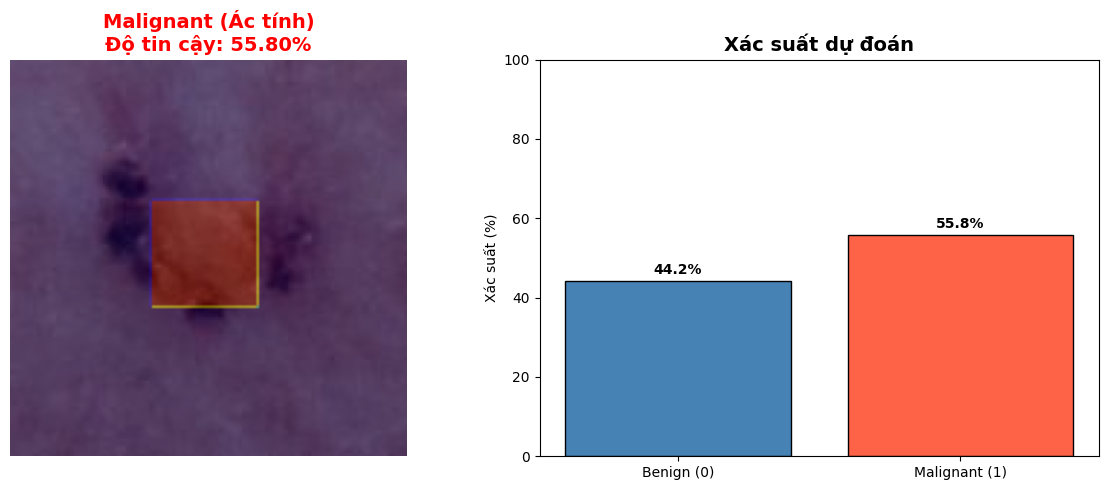

In [71]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder

# Đọc metadata ISIC 2024
df_metadata = pd.read_csv('/content/train-metadata.csv')

# Lọc các dòng có ảnh trong thư mục
available_ids = set([os.path.splitext(f)[0] for f in image_files])
df_available = df_metadata[df_metadata['isic_id'].isin(available_ids)].reset_index(drop=True)

# Lấy mẫu từ metadata
sample_row = df_available.iloc[1]  # Chọn dòng thứ 2
new_patient = sample_row.to_dict()
patient_image_path = os.path.join(image_folder, new_patient['isic_id'] + '.jpg')

# Recreate the full list of tabular columns and encoders, consistent with training
label_col = 'target'
id_col = 'isic_id'

exclude_cols = [label_col, id_col, 'patient_id', 'attribution', 'copyright_license',
                'image_type', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4',
                'iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'lesion_id']

numeric_cols_from_subset = df_subset.select_dtypes(include=np.number).columns.tolist()
full_tabular_columns = [col for col in numeric_cols_from_subset if col not in exclude_cols]

cat_cols_for_tabular = ['sex', 'anatom_site_general']
for col in cat_cols_for_tabular:
    if col in df_subset.columns and col not in full_tabular_columns:
        full_tabular_columns.append(col)

tabular_columns = full_tabular_columns

encoders = {}
for col in ['sex', 'anatom_site_general']:
    if col in df_subset.columns:
        le = LabelEncoder()
        le.fit(df_subset[col].astype(str))
        encoders[col] = le

# Gọi hàm dự đoán
diagnosis_result = predict_skin_lesion(model, df_available, patient_image_path, tabular_columns, encoders=encoders)

if diagnosis_result:
    # Trực quan hóa không có heatmap
    visualize_prediction(patient_image_path, diagnosis_result)

    # Tạo heatmap mẫu (mô phỏng vùng nghi ngờ)
    dummy_heatmap = np.zeros((224, 224))
    dummy_heatmap[80:140, 80:140] = 1.0

    # Trực quan hóa với heatmap
    visualize_prediction(patient_image_path, diagnosis_result, heatmap=dummy_heatmap)

/tmp/ipykernel_1297/3864985501.py:7: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df_metadata = pd.read_csv('/content/train-metadata.csv')
/tmp/ipykernel_1297/1921891425.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.fillna(0)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


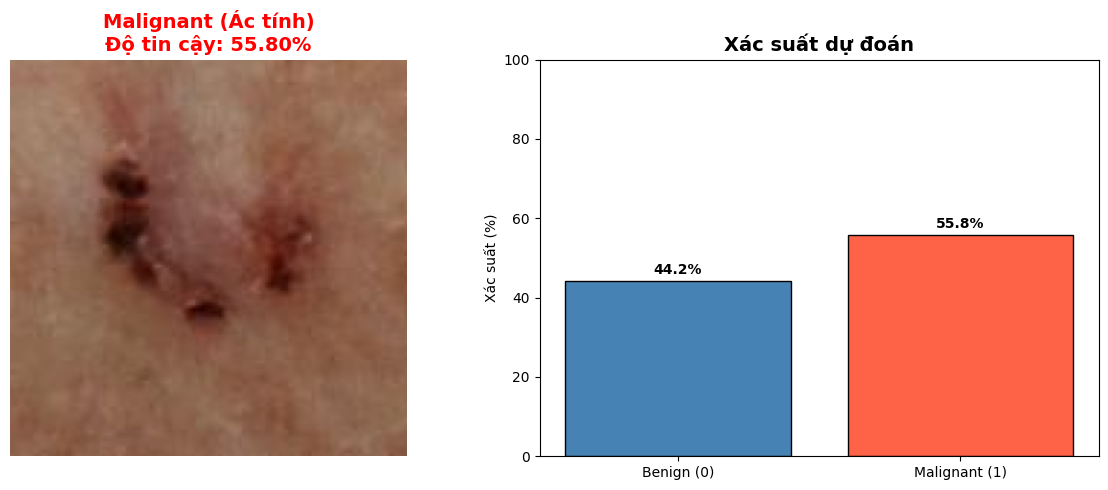

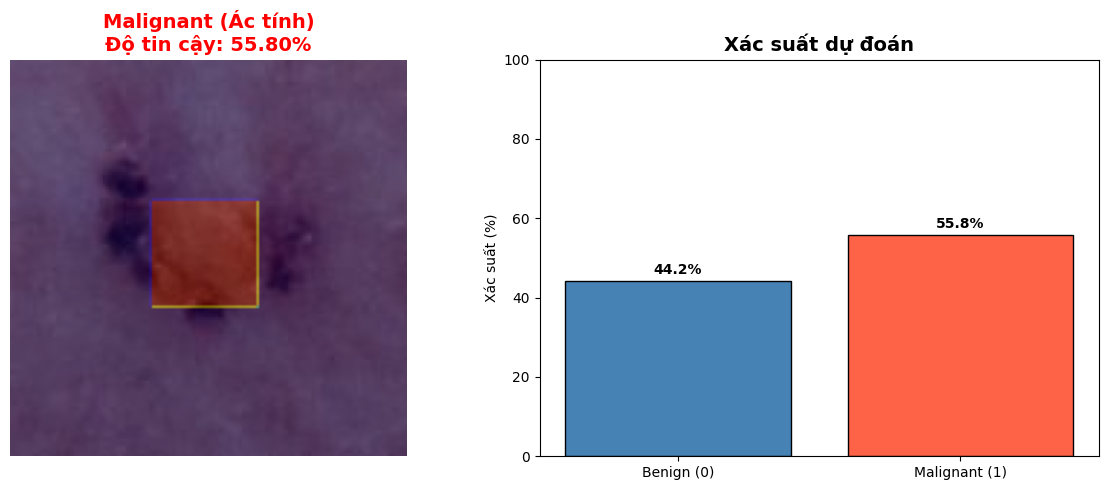

In [72]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder

# Đọc metadata ISIC 2024
df_metadata = pd.read_csv('/content/train-metadata.csv')

# Lọc các dòng có ảnh
available_ids = set([os.path.splitext(f)[0] for f in image_files])
df_available = df_metadata[df_metadata['isic_id'].isin(available_ids)].reset_index(drop=True)

# Lấy mẫu
sample_row = df_available.iloc[1]
new_patient = sample_row.to_dict()
patient_image_path = os.path.join(image_folder, new_patient['isic_id'] + '.jpg')

# Recreate the full list of tabular columns and encoders, consistent with training
label_col = 'target'
id_col = 'isic_id'

exclude_cols = [label_col, id_col, 'patient_id', 'attribution', 'copyright_license',
                'image_type', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4',
                'iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'lesion_id']

numeric_cols_from_subset = df_subset.select_dtypes(include=np.number).columns.tolist()
full_tabular_columns = [col for col in numeric_cols_from_subset if col not in exclude_cols]

cat_cols_for_tabular = ['sex', 'anatom_site_general']
for col in cat_cols_for_tabular:
    if col in df_subset.columns and col not in full_tabular_columns:
        full_tabular_columns.append(col)

tabular_columns = full_tabular_columns

encoders = {}
for col in ['sex', 'anatom_site_general']:
    if col in df_subset.columns:
        le = LabelEncoder()
        le.fit(df_subset[col].astype(str))
        encoders[col] = le

# Gọi hàm dự đoán
diagnosis_result = predict_skin_lesion(model, df_available, patient_image_path, tabular_columns, encoders=encoders)

if diagnosis_result:
    # Trực quan hóa không có heatmap
    visualize_prediction(patient_image_path, diagnosis_result)

    # Tạo heatmap mẫu
    dummy_heatmap = np.zeros((224, 224))
    dummy_heatmap[80:140, 80:140] = 1.0

    # Trực quan hóa với heatmap
    visualize_prediction(patient_image_path, diagnosis_result, heatmap=dummy_heatmap)